# Análisis de Desempeño Energético — Planta Industrial
### Prueba Técnica · Uptime Analytics
**Autor:** Andrés Rubiano
**Fecha:** Agosto 7 2026



Está organizado en las siguientes secciones:

1. Análisis del problema de negocio
2. Preparación del entorno y datos
3. Análisis exploratorio de los datos (EDA)
4. Cálculo de la línea base energética
5. Diagnóstico de desviaciones: ¿dónde y cuándo ocurren?
6. Cálculo de indicadores de desempeño energético
7. Impacto económico y priorización de acciones
8. Hallazgos principales
9. Conclusiones y recomendaciones

# 1. Análisis del problema de negocio

## ¿Cuál es la necesidad del cliente?

El cliente opera una planta industrial y necesita **evaluar el desempeño energético** de uno de sus procesos productivos. Específicamente, busca:

1. **Visibilidad**: Entender cuánta energía consume su proceso en relación con lo que debería consumir según su nivel de producción (línea base energética).
2. **Control**: Identificar desviaciones significativas entre el consumo real y el esperado, detectando ineficiencias o anomalías operativas de forma oportuna.
3. **Diagnóstico**: Saber **de dónde vienen** las desviaciones — ¿de la operación normal? ¿de los arranques? ¿del modo manual? — para saber dónde intervenir.
4. **Toma de decisiones**: Contar con indicadores claros (cumplimiento, ahorro, emisiones, impacto económico) que le permitan **priorizar acciones** por impacto económico real.
5. **Monitoreo continuo**: Disponer de una funcionalidad dentro del producto de Uptime Analytics que le permita hacer seguimiento periódico, no solo un análisis puntual.

## Preguntas antes de comenzar el desarrollo


1.  ¿Quién utilizará el dashboard? (operador de planta, gerente)

2. ¿Necesitan **alertas automáticas** por desviación y cómo llegarían?

3. ¿Los datos pueden verse en **tiempo real** (streaming, cada minuto)?
¿Cuál es la **tarifa eléctrica** vigente ($/kWh) para calcular el impacto económico con precisión?

4. ¿Existen **metas de reducción energética** establecidas (por ejemplo, en el marco de ISO 50001)?

5. ¿Las paradas identificadas son **programadas** (mantenimiento preventivo) o **no programadas** (fallas)?



# 2. Preparación del entorno y datos

In [4]:
!pip install -q pyarrow

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Entorno listo")

Entorno listo


In [6]:
df = pd.read_parquet("datos_sinteticos_planta (1).parquet")

## Verificación de los datos

Corroboramos el tamaño del dataset: efectivamente tiene **43,200 registros** (60 min × 24 h × 30 días) con **21 columnas** cada uno.

In [7]:
print(f"Dimensiones: {df.shape[0]:,} registros × {df.shape[1]} columnas")
df.head()

Dimensiones: 43,200 registros × 21 columnas


,Timestamp,Producción (t/h),Voltaje Fase A (V),Voltaje Fase B (V),Voltaje Fase C (V),Corriente Fase A (A),Corriente Fase B (A),Corriente Fase C (A),Potencia Activa (kW),Potencia Reactiva (kVAr),...,Factor de Potencia,Frecuencia Eléctrica (Hz),Temperatura del proceso (°C),Presión del proceso (bar),Caudal (m³/h),Velocidad (RPM),Torque (kN·m),Estado Operacional,Modo Operativo,Contador Energía Día (kWh)
0,2026-06-01 00:00:00,110.23,2403.5,2400.8,2405.2,177.3,179.2,177.0,1177.2,522.9,...,0.917,60.000,78.00,6.69,299.2,983.0,9.55,OPERANDO,AUTOMATICO,0.0
1,2026-06-01 00:01:00,109.60,2402.0,2400.4,2406.9,178.5,179.2,177.3,1176.5,520.7,...,0.915,60.000,77.94,6.65,293.0,979.0,9.54,OPERANDO,AUTOMATICO,19.6
2,2026-06-01 00:02:00,110.62,2403.1,2399.0,2405.6,179.4,179.3,179.7,1180.2,525.9,...,0.907,60.004,77.90,6.61,287.8,975.0,9.62,OPERANDO,AUTOMATICO,39.2
3,2026-06-01 00:03:00,110.89,2403.0,2398.2,2404.4,180.6,181.5,180.7,1192.0,525.7,...,0.916,60.010,77.87,6.54,283.4,974.0,9.74,OPERANDO,AUTOMATICO,58.9
4,2026-06-01 00:04:00,110.96,2401.8,2397.2,2403.0,179.9,181.5,180.3,1196.5,535.0,...,0.905,60.009,77.82,6.42,281.8,972.0,9.87,OPERANDO,AUTOMATICO,78.8


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     43200 non-null  datetime64[us]
 1   Producción (t/h)              43200 non-null  float64       
 2   Voltaje Fase A (V)            43200 non-null  float64       
 3   Voltaje Fase B (V)            43200 non-null  float64       
 4   Voltaje Fase C (V)            43200 non-null  float64       
 5   Corriente Fase A (A)          43200 non-null  float64       
 6   Corriente Fase B (A)          43200 non-null  float64       
 7   Corriente Fase C (A)          43200 non-null  float64       
 8   Potencia Activa (kW)          43200 non-null  float64       
 9   Potencia Reactiva (kVAr)      43200 non-null  float64       
 10  Potencia Aparente (kVA)       43200 non-null  float64       
 11  Factor de Potencia          

## Verificación de continuidad y completitud

In [9]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nRango temporal: {df['Timestamp'].min()} → {df['Timestamp'].max()}")
print(f"Frecuencia esperada: 1 minuto")

diferencias = df["Timestamp"].diff().dropna()
print(f"Intervalo mínimo: {diferencias.min()}")
print(f"Intervalo máximo: {diferencias.max()}")

Valores nulos por columna:
Timestamp                       0
Producción (t/h)                0
Voltaje Fase A (V)              0
Voltaje Fase B (V)              0
Voltaje Fase C (V)              0
Corriente Fase A (A)            0
Corriente Fase B (A)            0
Corriente Fase C (A)            0
Potencia Activa (kW)            0
Potencia Reactiva (kVAr)        0
Potencia Aparente (kVA)         0
Factor de Potencia              0
Frecuencia Eléctrica (Hz)       0
Temperatura del proceso (°C)    0
Presión del proceso (bar)       0
Caudal (m³/h)                   0
Velocidad (RPM)                 0
Torque (kN·m)                   0
Estado Operacional              0
Modo Operativo                  0
Contador Energía Día (kWh)      0
dtype: int64

Rango temporal: 2026-06-01 00:00:00 → 2026-06-30 23:59:00
Frecuencia esperada: 1 minuto
Intervalo mínimo: 0 days 00:01:00
Intervalo máximo: 0 days 00:01:00


Los datos están completos: **cero valores nulos**, cobertura continua del 1 al 30 de junio de 2026 con resolución de 1 minuto.

# 3. Análisis exploratorio de los datos

## 3.1 Estadísticas descriptivas

In [10]:
df.describe().T.sort_values(by="std", ascending=False)[["mean", "std", "min", "max"]]

,mean,std,min,max
Contador Energía Día (kWh),15439.522546,8969.469571,0.0,32671.1
Potencia Aparente (kVA),1403.231148,160.775627,176.1,1606.9
Potencia Activa (kW),1287.285854,152.761749,122.8,1470.9
Velocidad (RPM),985.822292,111.965408,0.0,1015.0
Potencia Reactiva (kVAr),557.505058,60.775444,124.4,689.4
Caudal (m³/h),307.527104,39.260396,1.3,356.6
Corriente Fase B (A),195.509359,22.439773,24.6,225.3
Corriente Fase A (A),195.273255,22.418915,24.6,223.6
Corriente Fase C (A),195.068019,22.37261,24.6,224.2
Producción (t/h),122.07312,16.116565,0.0,140.43


Excluyendo el Contador Energía Día (cuya naturaleza acumulativa genera una desviación estándar elevada), las variables con mayor variabilidad son **Potencia Aparente** (std = 160.78 kVA), **Potencia Activa** (std = 152.76 kW) y **Velocidad** (std = 111.97 RPM). Las variables eléctricas presentan las mayores fluctuaciones.

## 3.2 Estado operacional de la planta

In [11]:
estado_counts = df["Estado Operacional"].value_counts()
print(estado_counts)
print(f"\nTiempo operativo: {estado_counts['OPERANDO'] / len(df) * 100:.2f}%")

Estado Operacional
OPERANDO    42537
PARADO        441
PARANDO       112
ARRANQUE      110
Name: count, dtype: int64

Tiempo operativo: 98.47%


La planta estuvo en estado **OPERANDO** el 98.47% del tiempo. Solo el 1.53% corresponde a arranques, paradas y transiciones.

/tmp/ipykernel_1539/2302888798.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  estado_general = df["Estado Operacional"].replace({


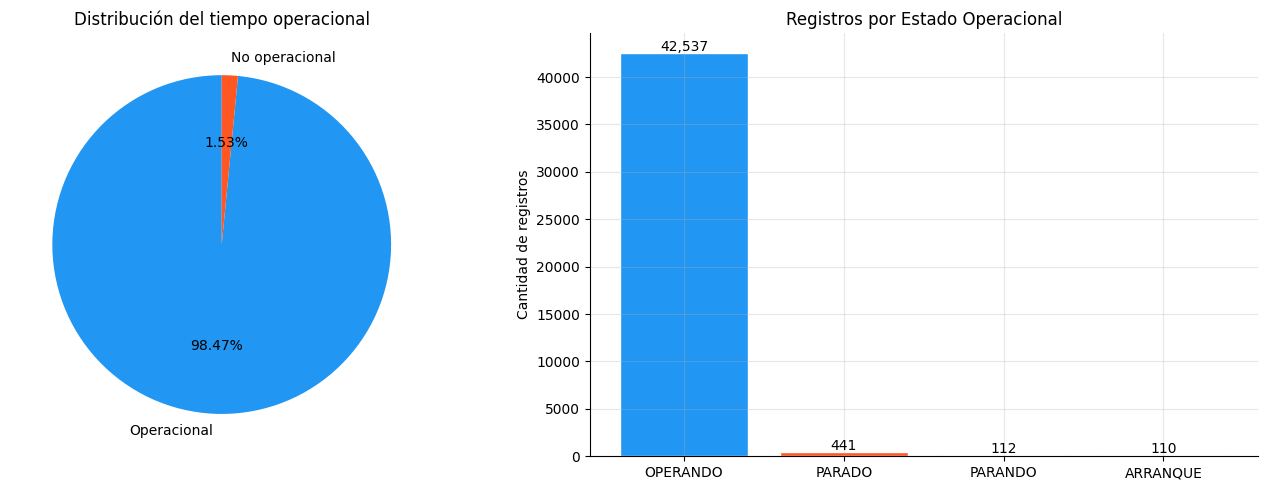

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: operacional vs no operacional
estado_general = df["Estado Operacional"].replace({
    "OPERANDO": "Operacional",
    "ARRANQUE": "No operacional",
    "PARANDO": "No operacional",
    "PARADO": "No operacional"
})
conteo_general = estado_general.value_counts()
axes[0].pie(conteo_general, labels=conteo_general.index, autopct="%1.2f%%", startangle=90,
            colors=["#2196F3", "#FF5722"])
axes[0].set_title("Distribución del tiempo operacional")

# Bar chart: detalle por estado
colors_estado = {"OPERANDO": "#2196F3", "PARADO": "#FF5722", "PARANDO": "#FF9800", "ARRANQUE": "#FFC107"}
bars = axes[1].bar(estado_counts.index, estado_counts.values,
                   color=[colors_estado.get(x, "#999") for x in estado_counts.index],
                   edgecolor="white")
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{bar.get_height():,}", ha="center", fontsize=10)
axes[1].set_title("Registros por Estado Operacional")
axes[1].set_ylabel("Cantidad de registros")

plt.tight_layout()
plt.show()

## 3.3 Modo operativo

In [13]:
modo_counts = df["Modo Operativo"].value_counts()
print(modo_counts)
print(f"\nTiempo en automático: {modo_counts['AUTOMATICO'] / len(df) * 100:.2f}%")

Modo Operativo
AUTOMATICO    42819
MANUAL          381
Name: count, dtype: int64

Tiempo en automático: 99.12%


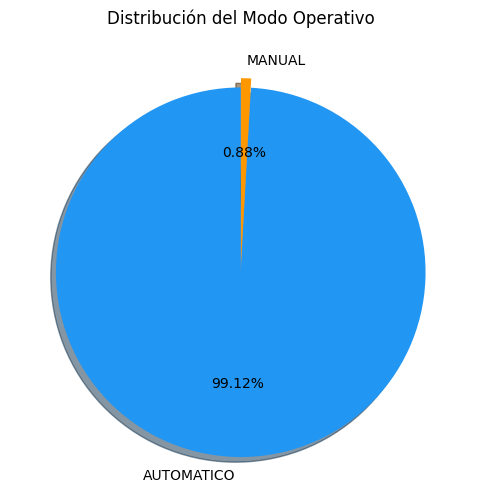

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(modo_counts, labels=modo_counts.index, autopct="%1.2f%%", startangle=90,
       explode=[0.05, 0], shadow=True, colors=["#2196F3", "#FF9800"])
ax.set_title("Distribución del Modo Operativo")
plt.show()

La planta opera en **modo automático** el 99.12% del tiempo. Solo el 0.88% fue en modo manual.

## 3.4 Producción a lo largo del mes

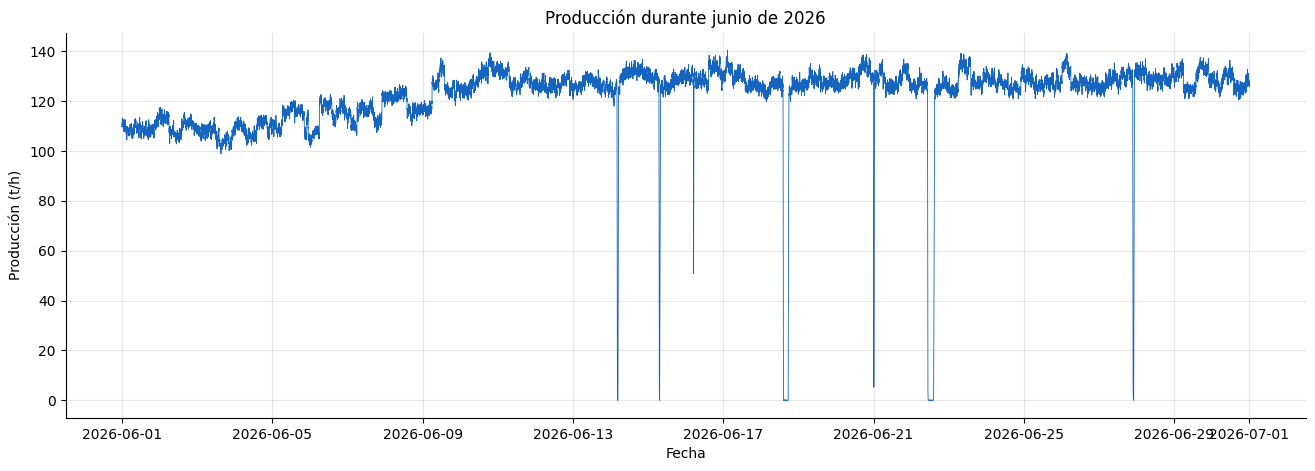

In [15]:
plt.figure(figsize=(16, 5))
plt.plot(df["Timestamp"], df["Producción (t/h)"], linewidth=0.6, color="#1565C0")
plt.title("Producción durante junio de 2026")
plt.xlabel("Fecha")
plt.ylabel("Producción (t/h)")
plt.show()

In [16]:
ceros = (df["Producción (t/h)"] == 0).sum()
print(f"La producción fue igual a 0 en {ceros} registros ({ceros} minutos = {ceros/60:.1f} horas).")

print("\nDistribución de minutos con producción = 0 por día:")
print(df.loc[df["Producción (t/h)"] == 0].groupby(df["Timestamp"].dt.date).size())

La producción fue igual a 0 en 365 registros (365 minutos = 6.1 horas).

Distribución de minutos con producción = 0 por día:
Timestamp
2026-06-14     11
2026-06-15      3
2026-06-18    150
2026-06-22    190
2026-06-27     11
dtype: int64


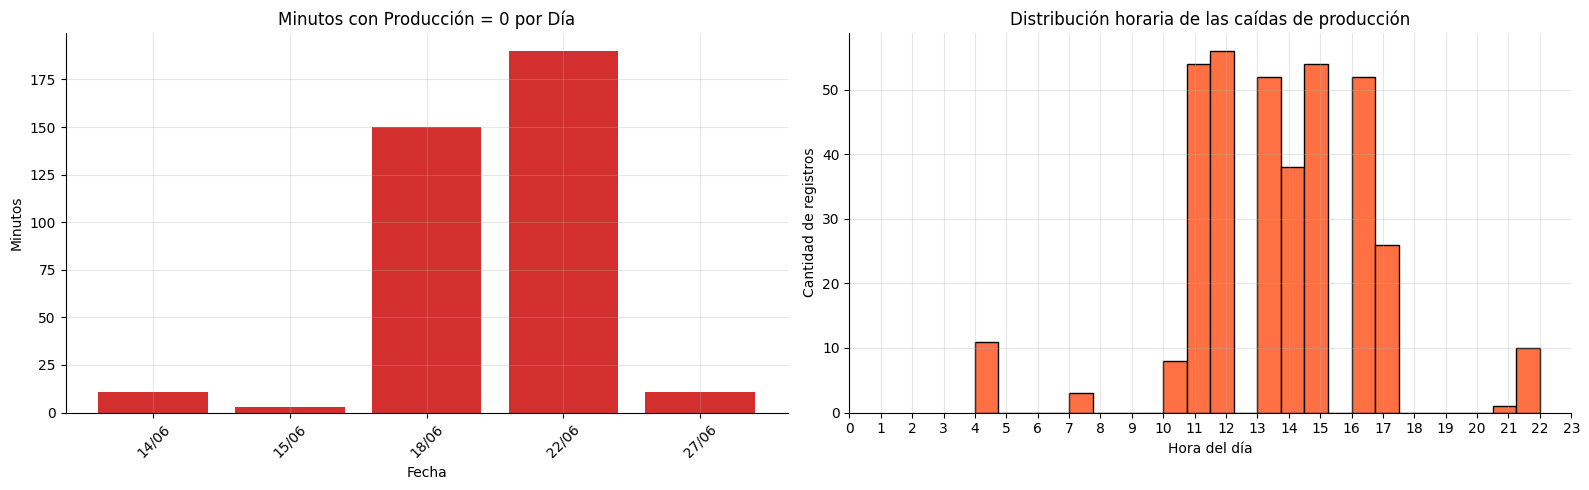

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Minutos con producción = 0 por día
produccion_cero = (
    df[df["Producción (t/h)"] == 0]
    .groupby(df["Timestamp"].dt.date)
    .size()
)
axes[0].bar(range(len(produccion_cero)), produccion_cero.values, color="#D32F2F")
axes[0].set_xticks(range(len(produccion_cero)))
axes[0].set_xticklabels([d.strftime("%d/%m") for d in produccion_cero.index], rotation=45)
axes[0].set_title("Minutos con Producción = 0 por Día")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Minutos")

# Distribución horaria de caídas
caidas = df[df["Producción (t/h)"] == 0]
axes[1].hist(caidas["Timestamp"].dt.hour, bins=24, edgecolor="black", color="#FF7043")
axes[1].set_xticks(range(24))
axes[1].set_title("Distribución horaria de las caídas de producción")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Cantidad de registros")

plt.tight_layout()
plt.show()

**Observaciones:**
- Los días **18 y 22 de junio** concentran la mayor cantidad de tiempo sin producción (150 y 190 minutos respectivamente).
- Las caídas tienden a concentrarse en franjas horarias específicas, lo que sugiere que responden a patrones operativos (mantenimiento programado, cambios de turno).

## 3.5 Potencia activa y correlaciones

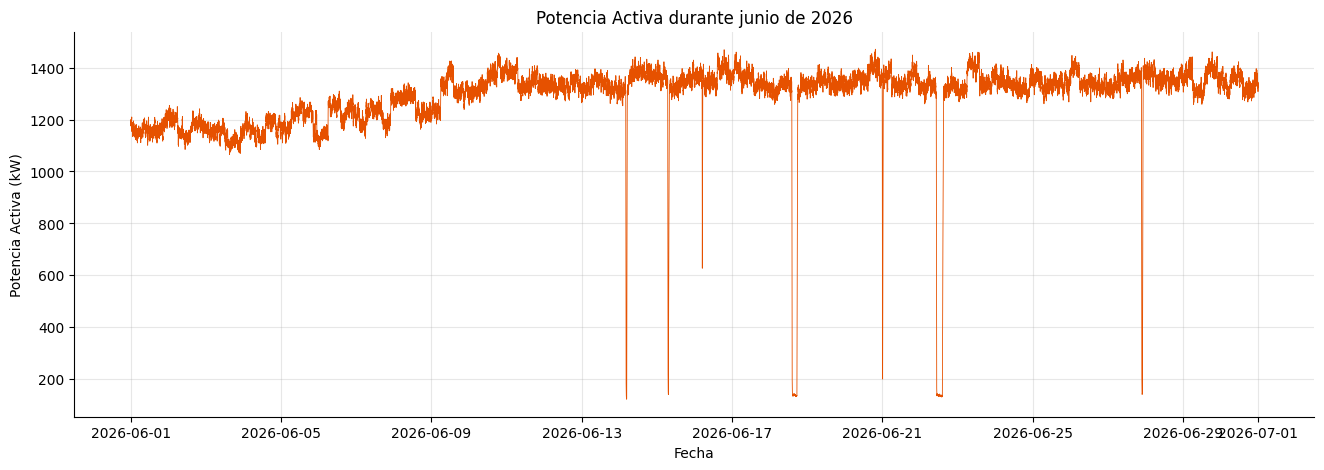

In [18]:
plt.figure(figsize=(16, 5))
plt.plot(df["Timestamp"], df["Potencia Activa (kW)"], linewidth=0.6, color="#E65100")
plt.title("Potencia Activa durante junio de 2026")
plt.xlabel("Fecha")
plt.ylabel("Potencia Activa (kW)")
plt.show()

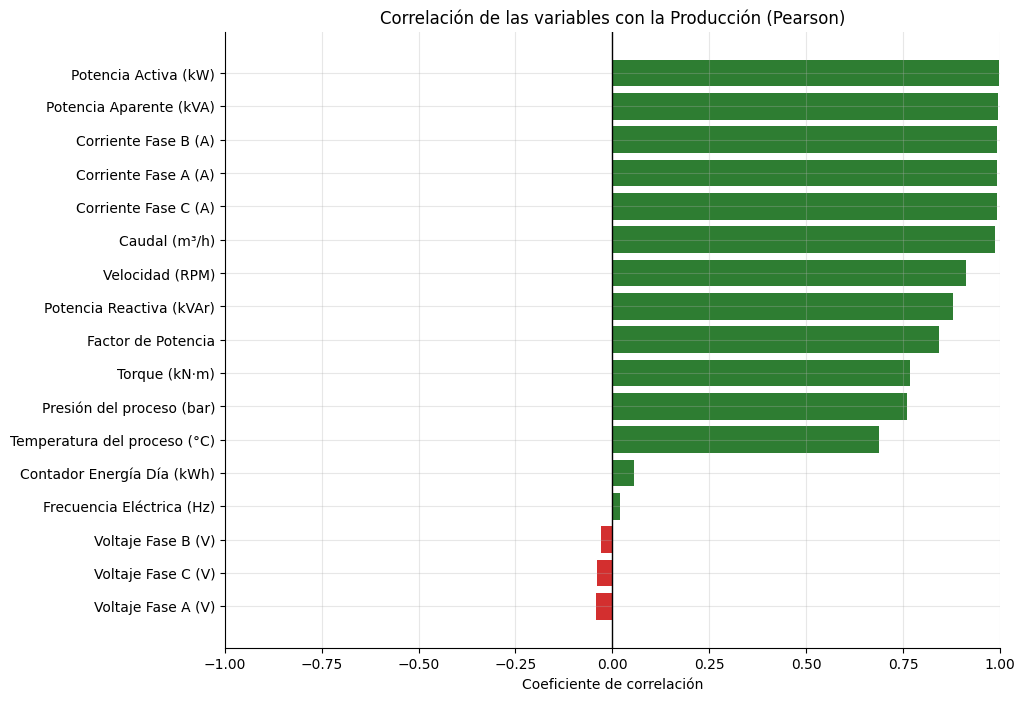

Correlación Producción vs Potencia Activa: 0.9974


In [19]:
correlaciones = (
    df.corr(numeric_only=True)["Producción (t/h)"]
    .drop("Producción (t/h)")
    .sort_values()
)

colores = ["#D32F2F" if x < 0 else "#2E7D32" for x in correlaciones]

plt.figure(figsize=(10, 8))
plt.barh(correlaciones.index, correlaciones.values, color=colores)
plt.axvline(0, color="black", linewidth=1)
plt.title("Correlación de las variables con la Producción (Pearson)")
plt.xlabel("Coeficiente de correlación")
plt.xlim(-1, 1)
plt.show()

print(f"Correlación Producción vs Potencia Activa: {df['Producción (t/h)'].corr(df['Potencia Activa (kW)']):.4f}")

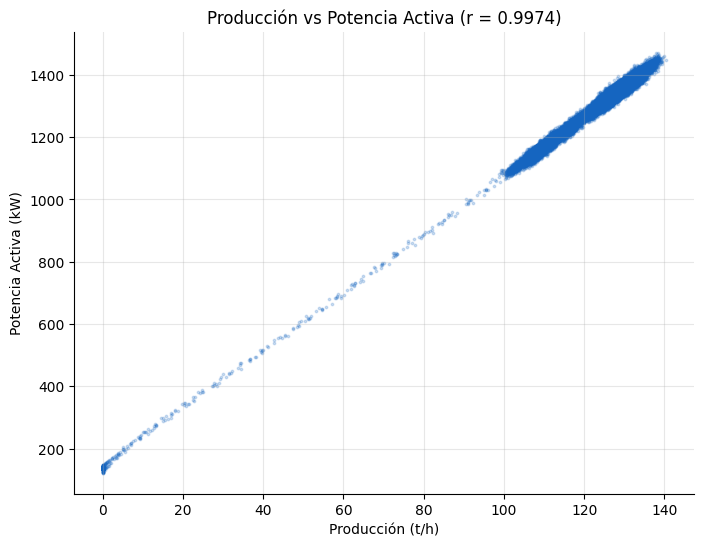

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Producción (t/h)"], df["Potencia Activa (kW)"],
            s=3, alpha=0.2, color="#1565C0")
plt.xlabel("Producción (t/h)")
plt.ylabel("Potencia Activa (kW)")
plt.title(f"Producción vs Potencia Activa (r = {df['Producción (t/h)'].corr(df['Potencia Activa (kW)']):.4f})")
plt.show()

La correlación de **0.9974** valida el modelo lineal de la línea base: la producción es el principal driver del consumo energético.

## 3.6 Análisis por estado operacional y modo operativo

In [21]:
print("Producción por Estado Operacional:")
print(df.groupby("Estado Operacional", observed=True)["Producción (t/h)"].agg(
    ["count", "mean", "std", "min", "max"]
))

print("\nPotencia Activa por Estado Operacional:")
print(df.groupby("Estado Operacional", observed=True)["Potencia Activa (kW)"].agg(
    ["mean", "std", "min", "max"]
))

Producción por Estado Operacional:
                    count        mean        std    min     max
Estado Operacional                                             
ARRANQUE              110   41.123909  21.818013   3.35   77.88
OPERANDO            42537  123.752038   8.290098  75.98  140.43
PARADO                441    0.063265   0.252278   0.00    1.82
PARANDO               112   44.346696  38.342472   1.88  119.23

Potencia Activa por Estado Operacional:
                           mean         std    min     max
Estado Operacional                                        
ARRANQUE             528.230909  200.199722  172.2   872.9
OPERANDO            1303.077523   80.270430  859.0  1470.9
PARADO               138.181859    5.101037  122.8   163.6
PARANDO              559.791964  356.012830  154.0  1263.0


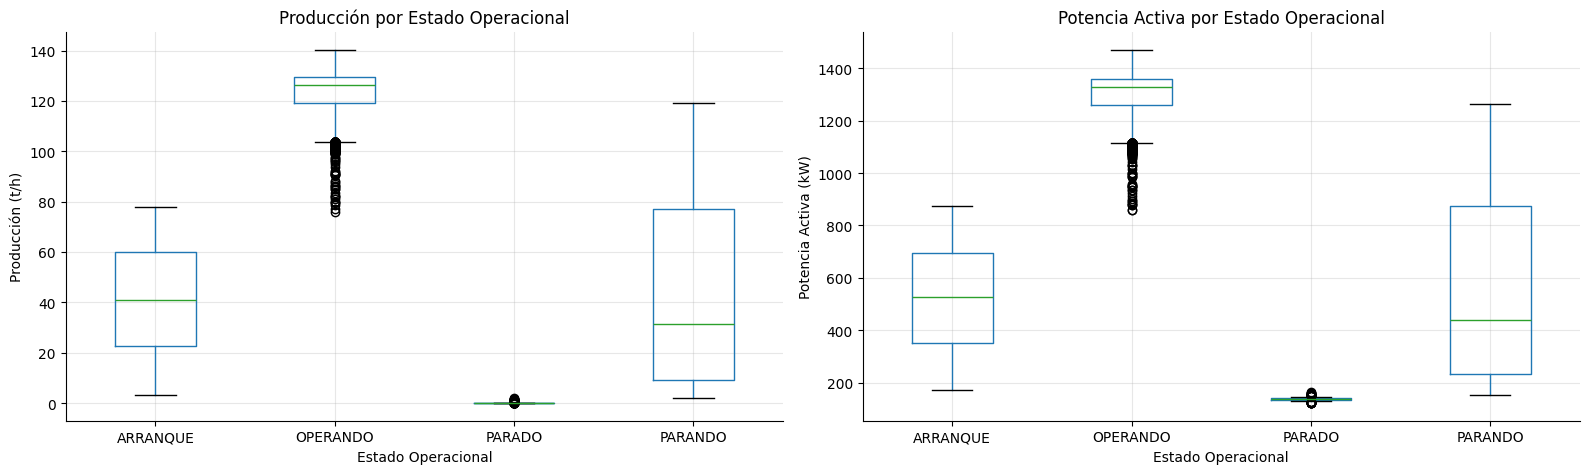

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.boxplot(column="Producción (t/h)", by="Estado Operacional", ax=axes[0])
axes[0].set_title("Producción por Estado Operacional")
axes[0].get_figure().suptitle("")
axes[0].set_ylabel("Producción (t/h)")

df.boxplot(column="Potencia Activa (kW)", by="Estado Operacional", ax=axes[1])
axes[1].set_title("Potencia Activa por Estado Operacional")
axes[1].get_figure().suptitle("")
axes[1].set_ylabel("Potencia Activa (kW)")

plt.tight_layout()
plt.show()

In [23]:
print("Comparación por Modo Operativo:")
print(df.groupby("Modo Operativo", observed=True)[
    ["Producción (t/h)", "Potencia Activa (kW)", "Factor de Potencia"]
].agg(["mean", "std"]))

Comparación por Modo Operativo:
               Producción (t/h)            Potencia Activa (kW)              \
                           mean        std                 mean         std   
Modo Operativo                                                                
AUTOMATICO           122.162645  15.901304          1288.104374  150.730940   
MANUAL               112.011759  30.571712          1195.295801  290.319971   

               Factor de Potencia            
                             mean       std  
Modo Operativo                               
AUTOMATICO               0.915348  0.022685  
MANUAL                   0.903906  0.036303  


**Observaciones:**
- En estado **OPERANDO**, la producción promedio es 123.75 t/h con baja variabilidad (std = 8.29).
- En modo **MANUAL**, la producción es más baja (112 vs 122 t/h) con mayor variabilidad (std = 30.57 vs 15.90) y peor factor de potencia (0.904 vs 0.915).

# 4. Cálculo de la línea base energética

Según la metodología proporcionada por Uptime Analytics:

> **Energía (kWh) = 0.159311 × Producción (t/h) + 2.002463**

R² = 0.9692. La ecuación estima la energía consumida **por minuto** en función del nivel de producción.

**Pregunta clave que responde esta sección: ¿La planta consume más o menos de lo esperado?**

In [24]:
# Energía esperada según la línea base (kWh por minuto)
df["Energia Esperada (kWh)"] = 0.159311 * df["Producción (t/h)"] + 2.002463

# Energía real consumida (kWh por minuto) = Potencia (kW) / 60
df["Energia Real (kWh)"] = df["Potencia Activa (kW)"] / 60

# Desviación absoluta y porcentual
df["Desviacion (kWh)"] = df["Energia Real (kWh)"] - df["Energia Esperada (kWh)"]
df["Desviacion (%)"] = (df["Desviacion (kWh)"] / df["Energia Esperada (kWh)"]) * 100

df[["Timestamp", "Producción (t/h)", "Potencia Activa (kW)",
    "Energia Esperada (kWh)", "Energia Real (kWh)",
    "Desviacion (kWh)", "Desviacion (%)"]].head(10)

,Timestamp,Producción (t/h),Potencia Activa (kW),Energia Esperada (kWh),Energia Real (kWh),Desviacion (kWh),Desviacion (%)
0,2026-06-01 00:00:00,110.23,1177.2,19.563315,19.620000,0.056685,0.289754
1,2026-06-01 00:01:00,109.60,1176.5,19.462949,19.608333,0.145385,0.746982
2,2026-06-01 00:02:00,110.62,1180.2,19.625446,19.670000,0.044554,0.227023
3,2026-06-01 00:03:00,110.89,1192.0,19.668460,19.866667,0.198207,1.007740
4,2026-06-01 00:04:00,110.96,1196.5,19.679612,19.941667,0.262055,1.331607
5,2026-06-01 00:05:00,111.36,1185.9,19.743336,19.765000,0.021664,0.109728
6,2026-06-01 00:06:00,110.59,1186.5,19.620666,19.775000,0.154334,0.786586
7,2026-06-01 00:07:00,111.39,1193.1,19.748115,19.885000,0.136885,0.693153
8,2026-06-01 00:08:00,111.44,1189.1,19.756081,19.818333,0.062252,0.315105
9,2026-06-01 00:09:00,111.33,1184.7,19.738557,19.745000,0.006443,0.032644


In [25]:
print("Estadísticas de la línea base y desviaciones:")
print(df[["Energia Esperada (kWh)", "Energia Real (kWh)",
          "Desviacion (kWh)", "Desviacion (%)"]].describe())

Estadísticas de la línea base y desviaciones:
       Energia Esperada (kWh)  Energia Real (kWh)  Desviacion (kWh)  \
count            43200.000000        43200.000000      43200.000000   
mean                21.450054           21.454764          0.004710   
std                  2.567546            2.546029          0.186676   
min                  2.002463            2.046667         -0.703834   
25%                 20.796382           20.823333         -0.121755   
50%                 22.105918           22.103333          0.005407   
75%                 22.609341           22.623333          0.130151   
max                 24.374507           24.515000          0.831637   

       Desviacion (%)  
count    43200.000000  
mean         0.177258  
std          1.806119  
min         -3.442326  
25%         -0.563416  
50%          0.025340  
75%          0.603896  
max         24.013943  


## Respuesta a la pregunta 1: ¿Consume más o menos de lo esperado?

In [26]:
suma_real = df["Energia Real (kWh)"].sum()
suma_base = df["Energia Esperada (kWh)"].sum()
diferencia = suma_real - suma_base

print(f"Energía Real total del mes:     {suma_real:>12,.2f} kWh")
print(f"Energía Esperada total del mes: {suma_base:>12,.2f} kWh")
print(f"{'─' * 45}")
print(f"Diferencia (sobreconsumo):      {diferencia:>+12,.2f} kWh")
print(f"Diferencia relativa:            {diferencia/suma_real*100:>+12.4f} %")
print()

if diferencia > 0:
    print("→ La planta consumió LIGERAMENTE MÁS de lo esperado.")
    print(f"  El sobreconsumo ({diferencia:,.1f} kWh) representa el {diferencia/suma_real*100:.4f}% del consumo total.")
    print("  Es marginal pero medible y debería monitorearse.")
else:
    print("→ La planta consumió MENOS de lo esperado. Hay ahorro energético.")

Energía Real total del mes:       926,845.81 kWh
Energía Esperada total del mes:   926,642.33 kWh
─────────────────────────────────────────────
Diferencia (sobreconsumo):           +203.49 kWh
Diferencia relativa:                 +0.0220 %

→ La planta consumió LIGERAMENTE MÁS de lo esperado.
  El sobreconsumo (203.5 kWh) representa el 0.0220% del consumo total.
  Es marginal pero medible y debería monitorearse.


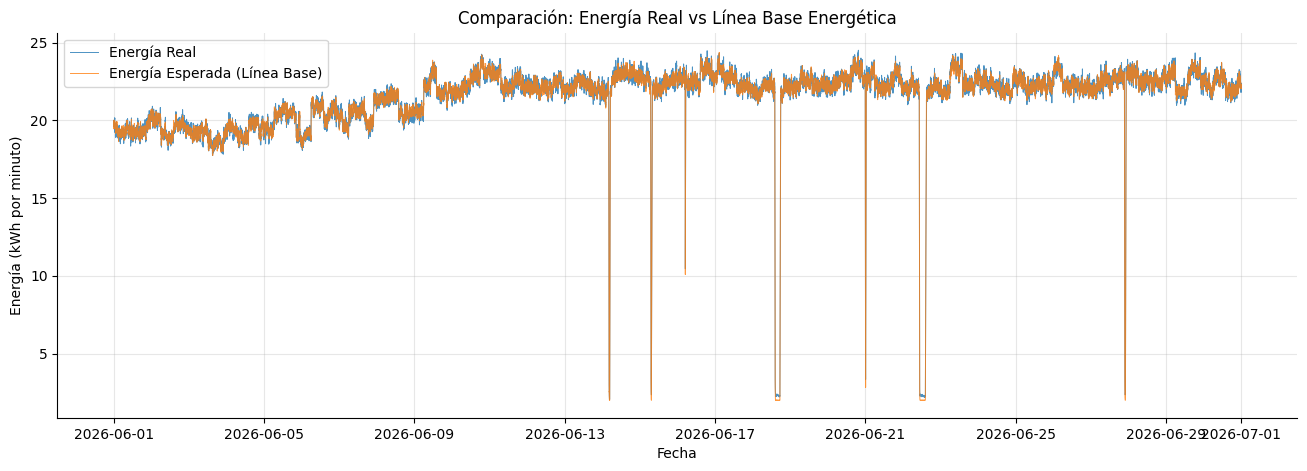

In [27]:
plt.figure(figsize=(16, 5))
plt.plot(df["Timestamp"], df["Energia Real (kWh)"], label="Energía Real", linewidth=0.7, alpha=0.8)
plt.plot(df["Timestamp"], df["Energia Esperada (kWh)"], label="Energía Esperada (Línea Base)",
         linewidth=0.7, alpha=0.8)
plt.title("Comparación: Energía Real vs Línea Base Energética")
plt.xlabel("Fecha")
plt.ylabel("Energía (kWh por minuto)")
plt.legend()
plt.show()

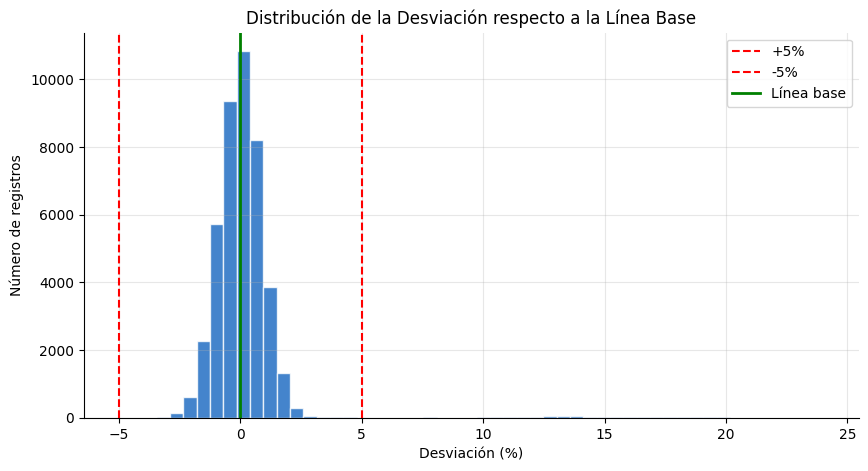

Registros dentro de ±5%: 42,680 de 43,200 (98.80%)


In [28]:
plt.figure(figsize=(10, 5))
plt.hist(df["Desviacion (%)"], bins=50, edgecolor="white", color="#1565C0", alpha=0.8)
plt.axvline(5, color="red", linestyle="--", linewidth=1.5, label="+5%")
plt.axvline(-5, color="red", linestyle="--", linewidth=1.5, label="-5%")
plt.axvline(0, color="green", linestyle="-", linewidth=2, label="Línea base")
plt.title("Distribución de la Desviación respecto a la Línea Base")
plt.xlabel("Desviación (%)")
plt.ylabel("Número de registros")
plt.legend()
plt.show()

tolerancia = 5
cumplen = (df["Desviacion (%)"].abs() <= tolerancia).sum()
porcentaje = cumplen / len(df) * 100
print(f"Registros dentro de ±{tolerancia}%: {cumplen:,} de {len(df):,} ({porcentaje:.2f}%)")

# 5. Diagnóstico de desviaciones: ¿Dónde y cuándo ocurren?

## 5.1 ¿De qué estado operacional proviene la desviación?

Desglosamos el sobreconsumo total por cada estado operacional para saber **dónde está la raíz** del problema.

In [29]:
# Desviación total acumulada por estado operacional
desv_por_estado = df.groupby("Estado Operacional", observed=True).agg(
    Registros=("Desviacion (kWh)", "count"),
    Desviacion_total_kWh=("Desviacion (kWh)", "sum"),
    Desviacion_media_kWh=("Desviacion (kWh)", "mean"),
    Desviacion_media_pct=("Desviacion (%)", "mean"),
    E_real_total=("Energia Real (kWh)", "sum"),
    E_base_total=("Energia Esperada (kWh)", "sum"),
).round(4)

desv_por_estado["% del sobreconsumo total"] = (
    desv_por_estado["Desviacion_total_kWh"] / desv_por_estado["Desviacion_total_kWh"].sum() * 100
).round(2)

print("=" * 75)
print("  DESGLOSE DE LA DESVIACIÓN ENERGÉTICA POR ESTADO OPERACIONAL")
print("=" * 75)
print(desv_por_estado[["Registros", "Desviacion_total_kWh",
                        "Desviacion_media_kWh", "% del sobreconsumo total"]])
print()
print("→ Esto nos dice de DÓNDE viene la desviación.")

  DESGLOSE DE LA DESVIACIÓN ENERGÉTICA POR ESTADO OPERACIONAL
                    Registros  Desviacion_total_kWh  Desviacion_media_kWh  \
Estado Operacional                                                          
ARRANQUE                  110               27.4884                0.2499   
OPERANDO                42537               18.4964                0.0004   
PARADO                    441              128.1057                0.2905   
PARANDO                   112               29.3985                0.2625   

                    % del sobreconsumo total  
Estado Operacional                            
ARRANQUE                               13.51  
OPERANDO                                9.09  
PARADO                                 62.95  
PARANDO                                14.45  

→ Esto nos dice de DÓNDE viene la desviación.


El 90.91% de la desviación energética (≈185 kWh) ocurre fuera del régimen normal de producción, principalmente en el estado PARADO (62.95%). Aunque ARRANQUE, PARADO y PARANDO representan solo el 1.53% de los registros, concentran casi toda la desviación. Esto indica que la principal oportunidad de mejora está en los periodos de inactividad y transición, donde deben investigarse consumos auxiliares, cargas en espera y secuencias de arranque/apagado.

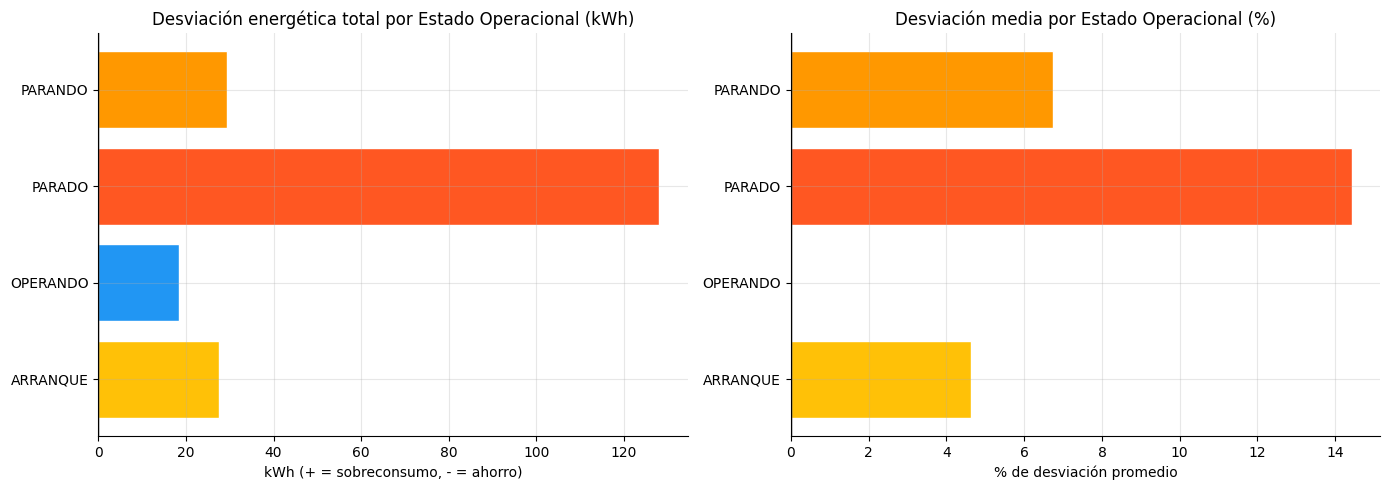

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Desviación total por estado
colors_estado = {"OPERANDO": "#2196F3", "PARADO": "#FF5722", "PARANDO": "#FF9800", "ARRANQUE": "#FFC107"}
estados = desv_por_estado.index.tolist()
vals = desv_por_estado["Desviacion_total_kWh"].values
colors = [colors_estado.get(e, "#999") for e in estados]
bar_colors = ["#D32F2F" if v > 0 else "#2E7D32" for v in vals]

axes[0].barh(estados, vals, color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Desviación energética total por Estado Operacional (kWh)")
axes[0].set_xlabel("kWh (+ = sobreconsumo, - = ahorro)")

# Desviación media por estado
axes[1].barh(estados, desv_por_estado["Desviacion_media_pct"].values, color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Desviación media por Estado Operacional (%)")
axes[1].set_xlabel("% de desviación promedio")

plt.tight_layout()
plt.show()

## 5.2 ¿El modo operativo influye en la desviación?

In [31]:
desv_por_modo = df.groupby("Modo Operativo", observed=True).agg(
    Registros=("Desviacion (kWh)", "count"),
    Desviacion_total_kWh=("Desviacion (kWh)", "sum"),
    Desviacion_media_kWh=("Desviacion (kWh)", "mean"),
    Desviacion_media_pct=("Desviacion (%)", "mean"),
).round(4)

desv_por_modo["% del sobreconsumo total"] = (
    desv_por_modo["Desviacion_total_kWh"] / desv_por_modo["Desviacion_total_kWh"].sum() * 100
).round(2)

print("=" * 75)
print("  DESGLOSE DE LA DESVIACIÓN ENERGÉTICA POR MODO OPERATIVO")
print("=" * 75)
print(desv_por_modo)

  DESGLOSE DE LA DESVIACIÓN ENERGÉTICA POR MODO OPERATIVO
                Registros  Desviacion_total_kWh  Desviacion_media_kWh  \
Modo Operativo                                                          
AUTOMATICO          42819              175.1318                0.0041   
MANUAL                381               28.3572                0.0744   

                Desviacion_media_pct  % del sobreconsumo total  
Modo Operativo                                                  
AUTOMATICO                    0.1723                     86.06  
MANUAL                        0.7360                     13.94  


El modo MANUAL presenta una desviación energética significativamente mayor que el AUTOMÁTICO. Aunque representa menos del 1% de los registros, concentra cerca del 14% del sobreconsumo y su desviación media por registro es aproximadamente 18 veces superior.

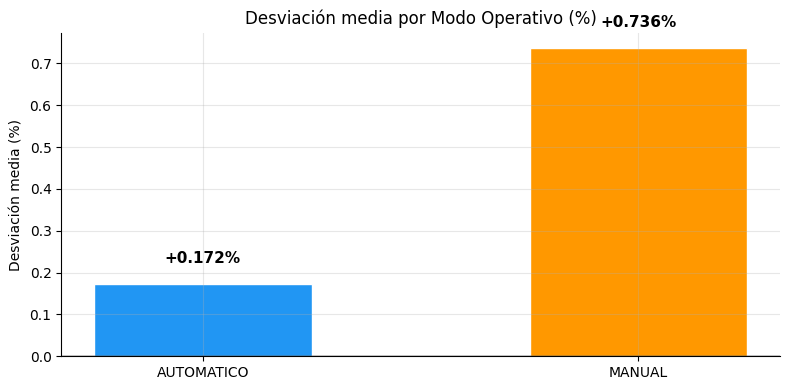

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
modos = desv_por_modo.index.tolist()
vals_modo = desv_por_modo["Desviacion_media_pct"].values
colors_modo_bar = ["#2196F3" if m == "AUTOMATICO" else "#FF9800" for m in modos]

bars = ax.bar(modos, vals_modo, color=colors_modo_bar, edgecolor="white", width=0.5)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Desviación media por Modo Operativo (%)")
ax.set_ylabel("Desviación media (%)")

for bar, val in zip(bars, vals_modo):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:+.3f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 5.3 ¿A qué hora del día ocurren las mayores desviaciones?

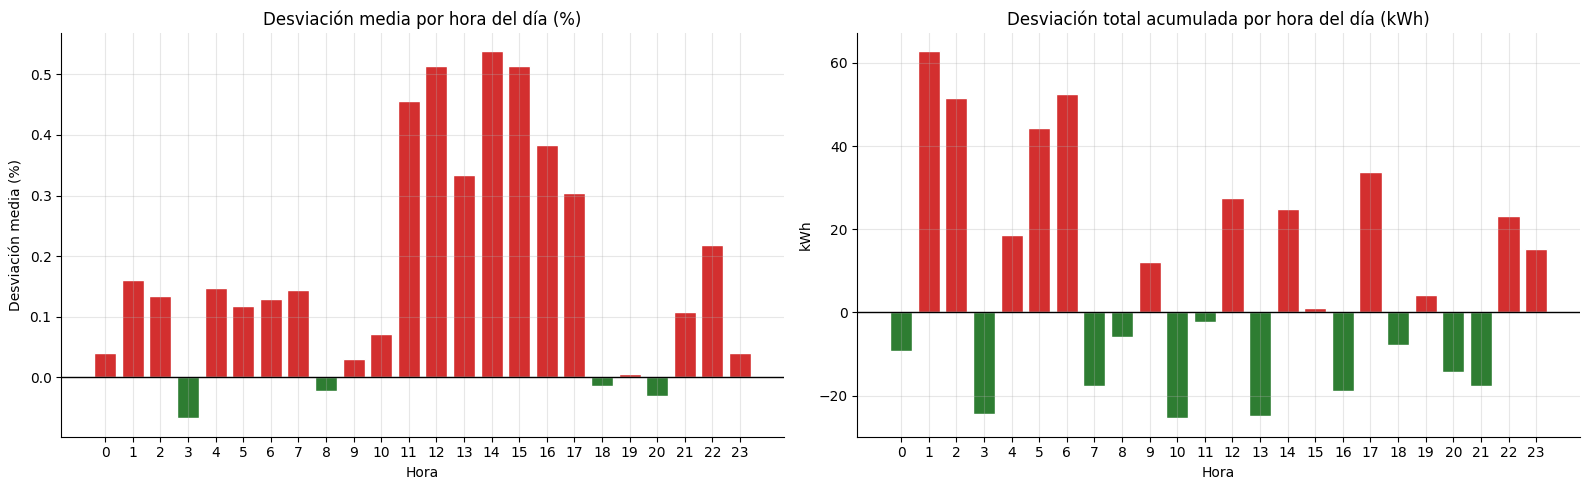

In [33]:
df["Hora"] = df["Timestamp"].dt.hour

desv_por_hora = df.groupby("Hora").agg(
    Desviacion_media_pct=("Desviacion (%)", "mean"),
    Desviacion_total_kWh=("Desviacion (kWh)", "sum"),
).round(4)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Media por hora
colores_hora = ["#D32F2F" if x > 0 else "#2E7D32" for x in desv_por_hora["Desviacion_media_pct"]]
axes[0].bar(desv_por_hora.index, desv_por_hora["Desviacion_media_pct"], color=colores_hora, edgecolor="white")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xticks(range(24))
axes[0].set_title("Desviación media por hora del día (%)")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Desviación media (%)")

# Acumulada por hora
colores_hora2 = ["#D32F2F" if x > 0 else "#2E7D32" for x in desv_por_hora["Desviacion_total_kWh"]]
axes[1].bar(desv_por_hora.index, desv_por_hora["Desviacion_total_kWh"], color=colores_hora2, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xticks(range(24))
axes[1].set_title("Desviación total acumulada por hora del día (kWh)")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("kWh")

plt.tight_layout()
plt.show()

## 5.4 ¿En qué días se concentra la desviación?

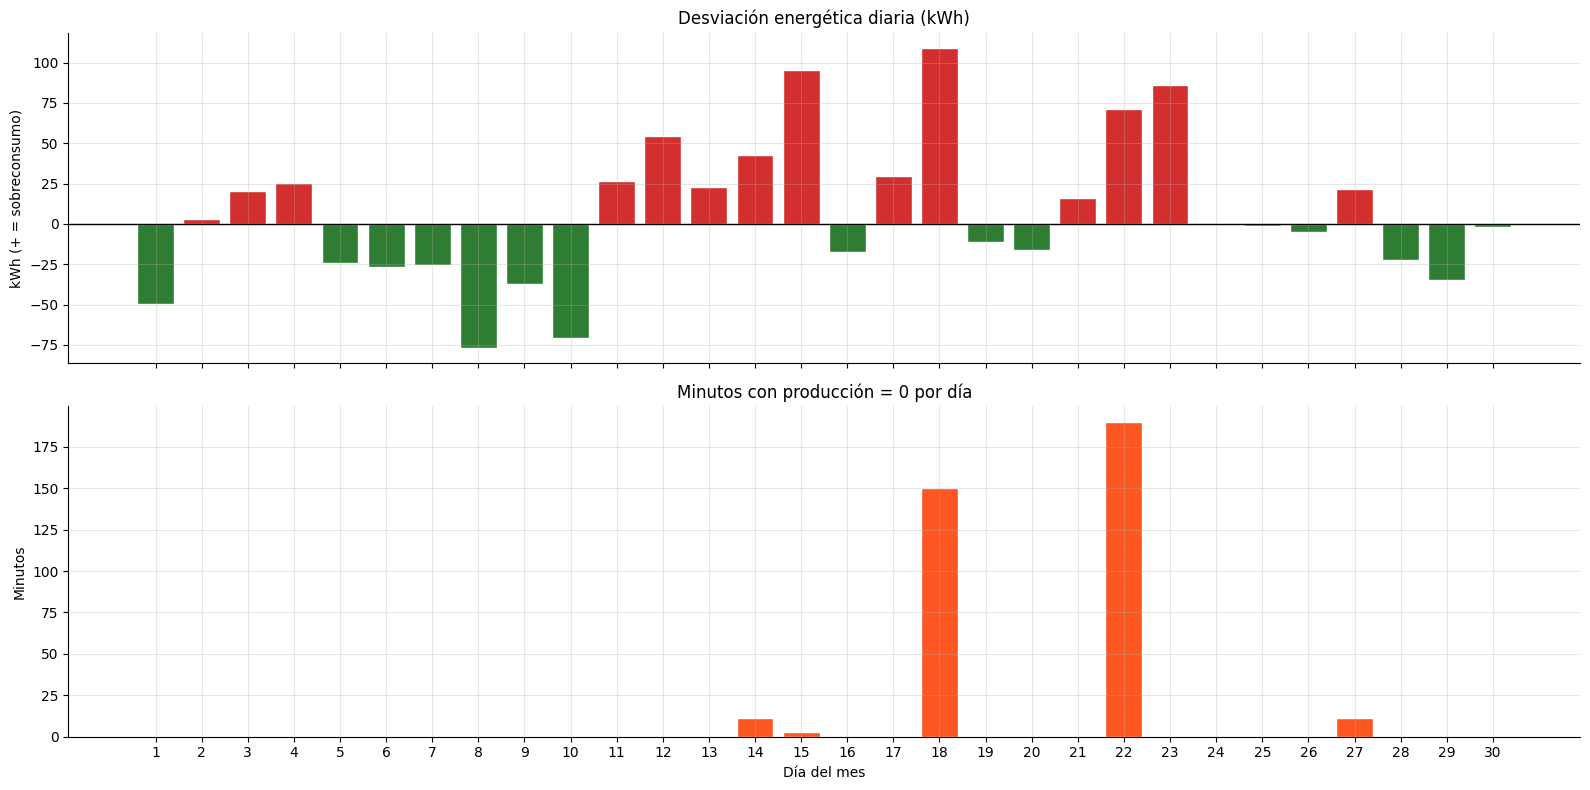

Top 5 días con MAYOR sobreconsumo:
     Fecha  Desviacion_total_kWh  Desviacion_media_pct  Min_parados
2026-06-18            109.093835              2.157595          150
2026-06-15             95.364595              0.532796            3
2026-06-23             86.107431              0.263226            0
2026-06-22             71.417830              2.263703          190
2026-06-12             54.689590              0.172185            0


In [34]:
df["Fecha"] = df["Timestamp"].dt.date

desv_por_dia = df.groupby("Fecha").agg(
    Desviacion_total_kWh=("Desviacion (kWh)", "sum"),
    Desviacion_media_pct=("Desviacion (%)", "mean"),
    Produccion_total_tons=("Producción (t/h)", lambda x: (x / 60).sum()),
    Min_parados=("Producción (t/h)", lambda x: (x == 0).sum()),
    E_real=("Energia Real (kWh)", "sum"),
    E_base=("Energia Esperada (kWh)", "sum"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Desviación diaria
colores_dia = ["#D32F2F" if x > 0 else "#2E7D32" for x in desv_por_dia["Desviacion_total_kWh"]]
axes[0].bar(range(30), desv_por_dia["Desviacion_total_kWh"], color=colores_dia, edgecolor="white")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Desviación energética diaria (kWh)")
axes[0].set_ylabel("kWh (+ = sobreconsumo)")

# Minutos parados
axes[1].bar(range(30), desv_por_dia["Min_parados"], color="#FF5722", edgecolor="white")
axes[1].set_title("Minutos con producción = 0 por día")
axes[1].set_ylabel("Minutos")
axes[1].set_xlabel("Día del mes")
axes[1].set_xticks(range(30))
axes[1].set_xticklabels(range(1, 31))

plt.tight_layout()
plt.show()

# Top 5 días con mayor sobreconsumo
print("Top 5 días con MAYOR sobreconsumo:")
print(desv_por_dia.nlargest(5, "Desviacion_total_kWh")[
    ["Fecha", "Desviacion_total_kWh", "Desviacion_media_pct", "Min_parados"]
].to_string(index=False))

La desviación energética presenta una alta variabilidad diaria, con picos de sobreconsumo superiores a 100 kWh en días específicos. Esto indica que la ineficiencia es principalmente episódica y justifica analizar qué condiciones operativas —paradas, modo manual, transiciones o periodos sin producción— coinciden con esos días críticos.

## 5.5 Cruce: Estado operacional × desviación (la tabla clave)

**¿De dónde viene exactamente el sobreconsumo y cuánto pesa cada fuente?**

In [35]:
# Cruce estado × modo
cruce = df.groupby(["Estado Operacional", "Modo Operativo"], observed=True).agg(
    Minutos=("Desviacion (kWh)", "count"),
    Desviacion_total_kWh=("Desviacion (kWh)", "sum"),
    Desviacion_media_pct=("Desviacion (%)", "mean"),
).round(4)

total_desv = df["Desviacion (kWh)"].sum()
cruce["% del total"] = (cruce["Desviacion_total_kWh"] / total_desv * 100).round(2)

print("=" * 80)
print("  DESGLOSE CRUZADO: ESTADO OPERACIONAL × MODO OPERATIVO")
print("=" * 80)
print(cruce)
print(f"\nDesviación total del mes: {total_desv:+,.2f} kWh")

  DESGLOSE CRUZADO: ESTADO OPERACIONAL × MODO OPERATIVO
                                   Minutos  Desviacion_total_kWh  \
Estado Operacional Modo Operativo                                  
ARRANQUE           AUTOMATICO           78               20.7142   
                   MANUAL               32                6.7742   
OPERANDO           AUTOMATICO        42203                0.6577   
                   MANUAL              334               17.8387   
PARADO             AUTOMATICO          436              127.7727   
                   MANUAL                5                0.3330   
PARANDO            AUTOMATICO          102               25.9871   
                   MANUAL               10                3.4114   

                                   Desviacion_media_pct  % del total  
Estado Operacional Modo Operativo                                     
ARRANQUE           AUTOMATICO                    5.0746        10.18  
                   MANUAL                        3

### Interpretación del cruce

El principal origen del sobreconsumo es el estado PARADO en modo AUTOMÁTICO, que aporta 127.77 kWh y representa el 62.79% de la desviación total. Si se agregan ARRANQUE y PARANDO en automático, los estados de inactividad y transición concentran el 85.74% del sobreconsumo. Esto indica que la prioridad de mejora debe centrarse en revisar qué equipos o cargas permanecen energizados durante las paradas y las secuencias automáticas de arranque y apagado.

Con estos números podemos **priorizar acciones** en la siguiente sección.

# 6. Cálculo de indicadores de desempeño energético




In [36]:
# ============================================================
# PARÁMETROS
# ============================================================
FACTOR_EMISION = 0.1000    # kgCO₂eq/kWh (proporcionado)
TARIFA_ELECTRICA = 700     # $/kWh (referencia industrial, debe confirmarse con el cliente)

# ============================================================
# SUMATORIAS DEL PERÍODO
# ============================================================
suma_energia_real = df["Energia Real (kWh)"].sum()
suma_energia_base = df["Energia Esperada (kWh)"].sum()
suma_produccion_tons = (df["Producción (t/h)"] / 60).sum()

print(f"Σ Energía Real:     {suma_energia_real:>12,.2f} kWh")
print(f"Σ Energía Base:     {suma_energia_base:>12,.2f} kWh")
print(f"Σ Producción:       {suma_produccion_tons:>12,.2f} toneladas")
print(f"Diferencia:         {suma_energia_real - suma_energia_base:>+12,.2f} kWh")

Σ Energía Real:       926,845.81 kWh
Σ Energía Base:       926,642.33 kWh
Σ Producción:          87,892.65 toneladas
Diferencia:              +203.49 kWh


  INDICADORES DE DESEMPEÑO ENERGÉTICO — JUNIO 2026
  1. Cumplimiento:            99.98%
  2. Desempeño energético:    +203.49 kWh
  3. GEI:                     +0.2315 kgCO₂eq
  4. Desempeño económico:     Parametrizado — pendiente de tarifa eléctrica
  5. Ahorro:                  +0.0220%
  6. Índice de consumo:       10.5452 kWh/t

Desempeño económico parametrizado: no es posible calcular un valor monetario con los insumos suministrados, ya que la tarifa eléctrica ($/kWh) no fue proporcionada. El indicador queda definido para calcularse automáticamente cuando el cliente configure su tarifa.

Fórmula del desempeño económico: +203.49 kWh × Tarifa eléctrica ($/kWh)
Factor de emisión: 0.1 kgCO₂eq/kWh (proporcionado)


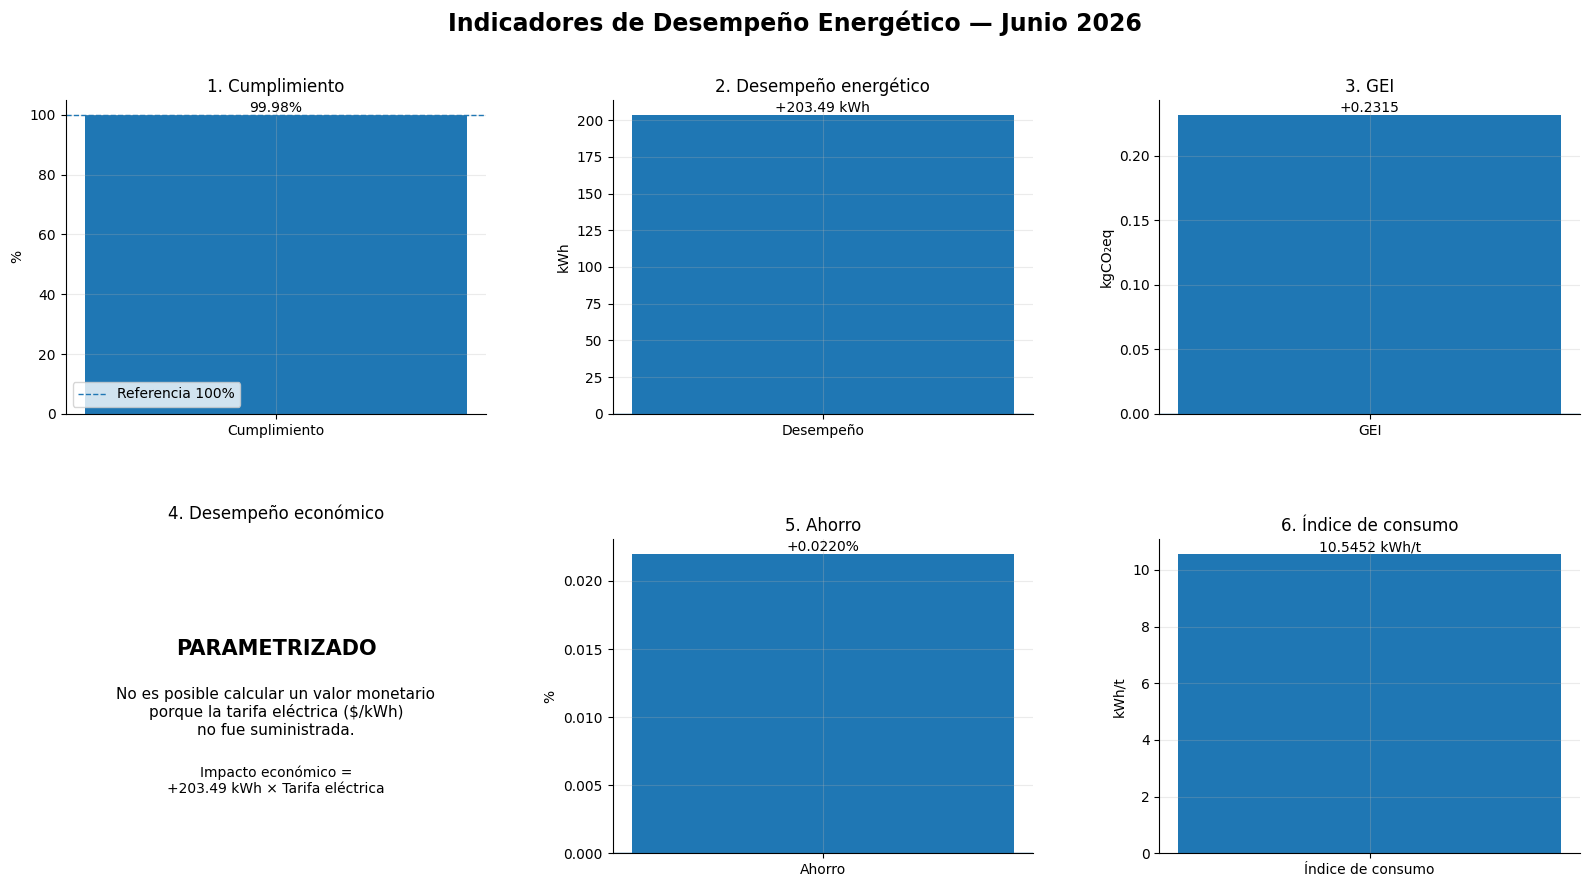

In [37]:
import matplotlib.pyplot as plt

# ============================================================
# CÁLCULO DE LOS 6 INDICADORES
# ============================================================

# 1. Cumplimiento (%)
# Σ Energía_base / Σ Energía_real
cumplimiento = (suma_energia_base / suma_energia_real) * 100


# 2. Desempeño Energético (kWh)
# Σ Energía_real - Σ Energía_base
desempeno_kwh = suma_energia_real - suma_energia_base


# 3. GEI (kgCO₂eq)
# ((Σ E_real - Σ E_base) / Σ Producción)
# × Factor de emisión × 1000
gei = (
    (desempeno_kwh / suma_produccion_tons)
    * FACTOR_EMISION
    * 1000
)


# 4. Desempeño Económico
# (Σ E_real - Σ E_base) × Tarifa eléctrica
#
# La tarifa eléctrica NO fue suministrada en el caso.
# Por lo tanto, el indicador se mantiene parametrizado.

TARIFA_ELECTRICA = None


def calcular_desempeno_economico(tarifa_electrica):
    return desempeno_kwh * tarifa_electrica


if TARIFA_ELECTRICA is not None:
    desempeno_economico = calcular_desempeno_economico(
        TARIFA_ELECTRICA
    )
else:
    desempeno_economico = None


# 5. Ahorro (%)
# (Σ E_real - Σ E_base) / Σ E_real
ahorro = (
    desempeno_kwh / suma_energia_real
) * 100


# 6. Índice de Consumo (kWh/t)
# Σ E_real / Σ Producción
indice_consumo = (
    suma_energia_real / suma_produccion_tons
)


# ============================================================
# RESULTADOS
# ============================================================

print("=" * 80)
print(
    "  INDICADORES DE DESEMPEÑO ENERGÉTICO — JUNIO 2026"
)
print("=" * 80)

print(
    f"  1. Cumplimiento:            "
    f"{cumplimiento:.2f}%"
)

print(
    f"  2. Desempeño energético:    "
    f"{desempeno_kwh:+,.2f} kWh"
)

print(
    f"  3. GEI:                     "
    f"{gei:+,.4f} kgCO₂eq"
)

if desempeno_economico is not None:
    print(
        f"  4. Desempeño económico:     "
        f"{desempeno_economico:+,.2f}"
    )
else:
    print(
        "  4. Desempeño económico:     "
        "Parametrizado — pendiente de tarifa eléctrica"
    )

print(
    f"  5. Ahorro:                  "
    f"{ahorro:+,.4f}%"
)

print(
    f"  6. Índice de consumo:       "
    f"{indice_consumo:.4f} kWh/t"
)

print("=" * 80)

print(
    "\nDesempeño económico parametrizado: "
    "no es posible calcular un valor monetario con los "
    "insumos suministrados, ya que la tarifa eléctrica "
    "($/kWh) no fue proporcionada. El indicador queda "
    "definido para calcularse automáticamente cuando el "
    "cliente configure su tarifa."
)

print(
    f"\nFórmula del desempeño económico: "
    f"{desempeno_kwh:+,.2f} kWh × Tarifa eléctrica ($/kWh)"
)

print(
    f"Factor de emisión: "
    f"{FACTOR_EMISION} kgCO₂eq/kWh (proporcionado)"
)


# ============================================================
# GRÁFICA DE LOS 6 INDICADORES
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

fig.suptitle(
    "Indicadores de Desempeño Energético — Junio 2026",
    fontsize=17,
    fontweight="bold"
)


# ============================================================
# 1. CUMPLIMIENTO
# ============================================================

ax = axes[0, 0]

ax.bar(
    ["Cumplimiento"],
    [cumplimiento]
)

ax.axhline(
    100,
    linestyle="--",
    linewidth=1,
    label="Referencia 100%"
)

ax.set_ylabel("%")
ax.set_title("1. Cumplimiento")
ax.grid(axis="y", alpha=0.25)

ax.text(
    0,
    cumplimiento,
    f"{cumplimiento:.2f}%",
    ha="center",
    va="bottom"
)

ax.legend()


# ============================================================
# 2. DESEMPEÑO ENERGÉTICO
# ============================================================

ax = axes[0, 1]

ax.bar(
    ["Desempeño"],
    [desempeno_kwh]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_ylabel("kWh")
ax.set_title("2. Desempeño energético")
ax.grid(axis="y", alpha=0.25)

ax.text(
    0,
    desempeno_kwh,
    f"{desempeno_kwh:+,.2f} kWh",
    ha="center",
    va=(
        "bottom"
        if desempeno_kwh >= 0
        else "top"
    )
)


# ============================================================
# 3. GEI
# ============================================================

ax = axes[0, 2]

ax.bar(
    ["GEI"],
    [gei]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_ylabel("kgCO₂eq")
ax.set_title("3. GEI")
ax.grid(axis="y", alpha=0.25)

ax.text(
    0,
    gei,
    f"{gei:+,.4f}",
    ha="center",
    va=(
        "bottom"
        if gei >= 0
        else "top"
    )
)


# ============================================================
# 4. DESEMPEÑO ECONÓMICO PARAMETRIZADO
# ============================================================

ax = axes[1, 0]

# No existe valor numérico porque no se suministró tarifa.
ax.axis("off")

ax.set_title(
    "4. Desempeño económico",
    pad=15
)

ax.text(
    0.5,
    0.65,
    "PARAMETRIZADO",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    transform=ax.transAxes
)

ax.text(
    0.5,
    0.45,
    (
        "No es posible calcular un valor monetario\n"
        "porque la tarifa eléctrica ($/kWh)\n"
        "no fue suministrada."
    ),
    ha="center",
    va="center",
    fontsize=11,
    transform=ax.transAxes
)

ax.text(
    0.5,
    0.23,
    (
        f"Impacto económico =\n"
        f"{desempeno_kwh:+,.2f} kWh × Tarifa eléctrica"
    ),
    ha="center",
    va="center",
    fontsize=10,
    transform=ax.transAxes
)


# ============================================================
# 5. AHORRO
# ============================================================

ax = axes[1, 1]

ax.bar(
    ["Ahorro"],
    [ahorro]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_ylabel("%")
ax.set_title("5. Ahorro")
ax.grid(axis="y", alpha=0.25)

ax.text(
    0,
    ahorro,
    f"{ahorro:+,.4f}%",
    ha="center",
    va=(
        "bottom"
        if ahorro >= 0
        else "top"
    )
)


# ============================================================
# 6. ÍNDICE DE CONSUMO
# ============================================================

ax = axes[1, 2]

ax.bar(
    ["Índice de consumo"],
    [indice_consumo]
)

ax.set_ylabel("kWh/t")
ax.set_title("6. Índice de consumo")
ax.grid(axis="y", alpha=0.25)

ax.text(
    0,
    indice_consumo,
    f"{indice_consumo:.4f} kWh/t",
    ha="center",
    va="bottom"
)


# ============================================================
# AJUSTES FINALES
# ============================================================

plt.tight_layout()

plt.subplots_adjust(
    top=0.88,
    hspace=0.40,
    wspace=0.30
)

plt.show()

### Interpretación de los indicadores

| Indicador | Valor | Interpretación |
|---|---:|---|
| **Cumplimiento** | **99.98%** | El consumo energético agregado del período se encuentra muy próximo a la línea base establecida. |
| **Desempeño energético** | **+203.49 kWh** | Se presenta un sobreconsumo neto de 203.49 kWh respecto a la línea base energética. |
| **GEI** | **+0.2315 kgCO₂eq** | El sobreconsumo registrado genera emisiones adicionales de 0.2315 kgCO₂eq, según el factor de emisión suministrado. |
| **Desempeño económico** | **Parametrizado** | No es posible cuantificar el impacto monetario con los insumos suministrados, ya que no se proporcionó la tarifa eléctrica ($/kWh). El indicador queda definido para calcularse cuando el cliente configure dicha tarifa. |
| **Ahorro** | **+0.0220%** | Según la fórmula suministrada, el resultado es positivo porque la energía real supera la línea base. En este período representa sobreconsumo, no un ahorro energético efectivo. |
| **Índice de consumo** | **10.55 kWh/t** | Durante el período analizado se consumieron aproximadamente 10.55 kWh por cada tonelada producida. |

## 6.1 Evolución diaria de los indicadores



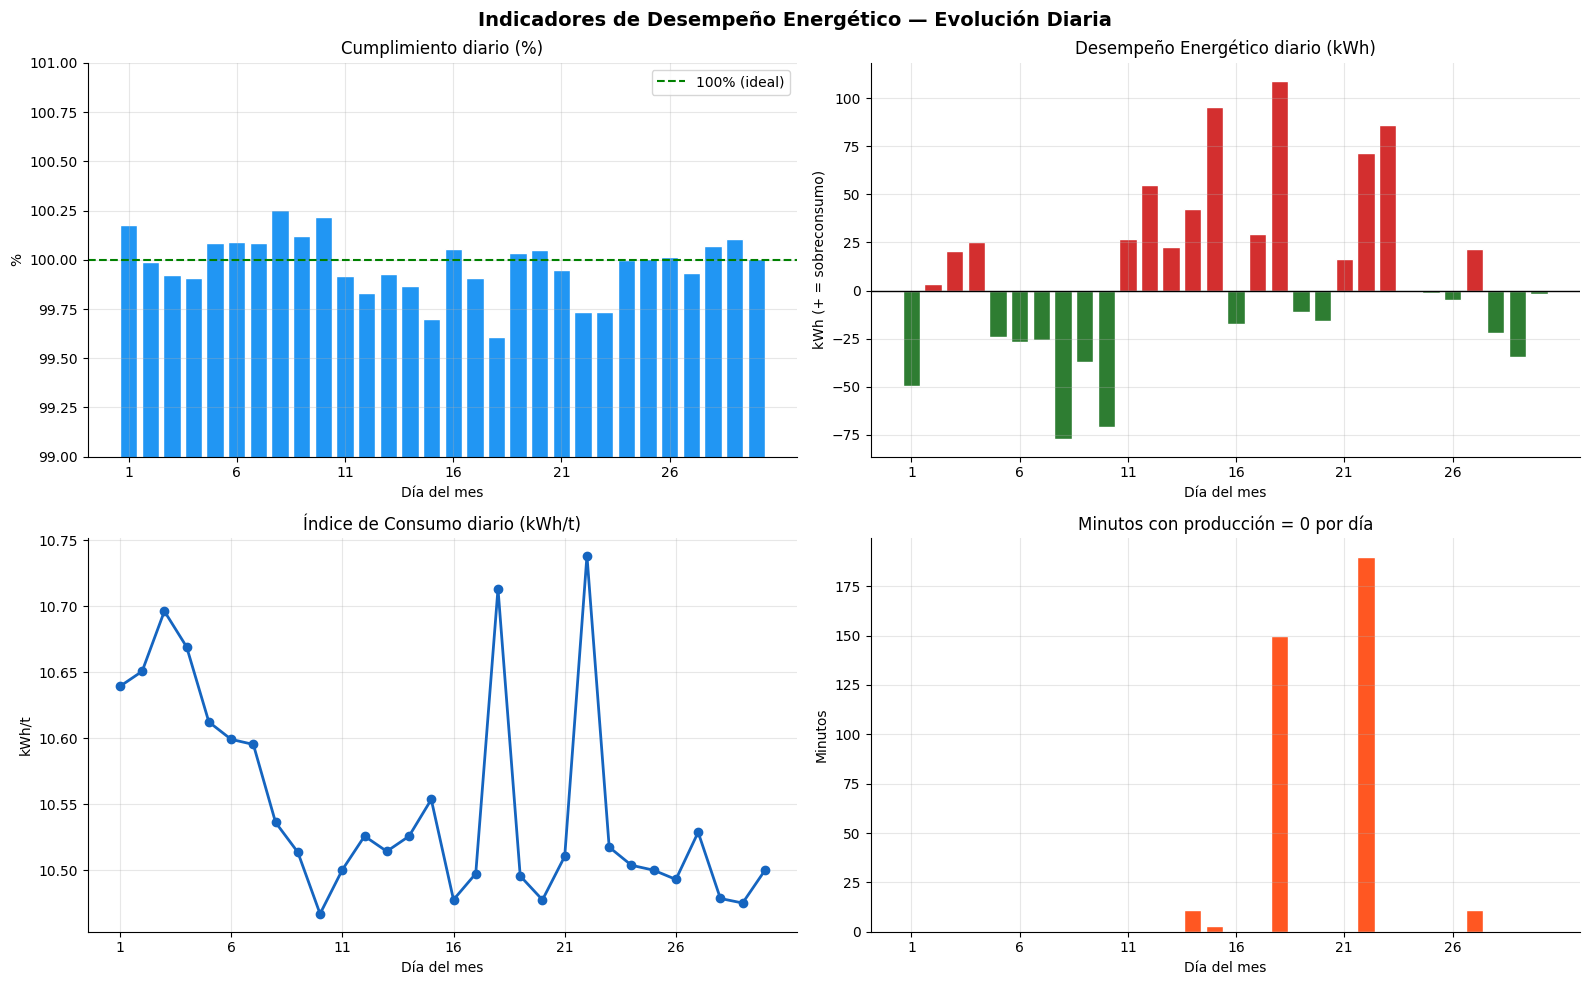

In [38]:
diario = desv_por_dia.copy()
diario["Cumplimiento (%)"] = (diario["E_base"] / diario["E_real"]) * 100
diario["Ahorro (%)"] = ((diario["E_real"] - diario["E_base"]) / diario["E_real"]) * 100
diario["Indice (kWh/t)"] = diario["E_real"] / diario["Produccion_total_tons"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cumplimiento diario
axes[0, 0].bar(range(30), diario["Cumplimiento (%)"], color="#2196F3", edgecolor="white")
axes[0, 0].axhline(100, color="green", linestyle="--", linewidth=1.5, label="100% (ideal)")
axes[0, 0].set_title("Cumplimiento diario (%)")
axes[0, 0].set_ylabel("%")
axes[0, 0].legend()
axes[0, 0].set_ylim(99, 101)

# Desempeño energético diario
colors_desemp = ["#D32F2F" if x > 0 else "#2E7D32" for x in diario["Desviacion_total_kWh"]]
axes[0, 1].bar(range(30), diario["Desviacion_total_kWh"], color=colors_desemp, edgecolor="white")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Desempeño Energético diario (kWh)")
axes[0, 1].set_ylabel("kWh (+ = sobreconsumo)")

# Índice de consumo diario
axes[1, 0].plot(range(30), diario["Indice (kWh/t)"], marker="o", color="#1565C0", linewidth=2)
axes[1, 0].set_title("Índice de Consumo diario (kWh/t)")
axes[1, 0].set_ylabel("kWh/t")

# Minutos sin producción por día
axes[1, 1].bar(range(30), diario["Min_parados"], color="#FF5722", edgecolor="white")
axes[1, 1].set_title("Minutos con producción = 0 por día")
axes[1, 1].set_ylabel("Minutos")

for ax in axes.flat:
    ax.set_xlabel("Día del mes")
    ax.set_xticks(range(0, 30, 5))
    ax.set_xticklabels(range(1, 31, 5))

plt.suptitle("Indicadores de Desempeño Energético — Evolución Diaria", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

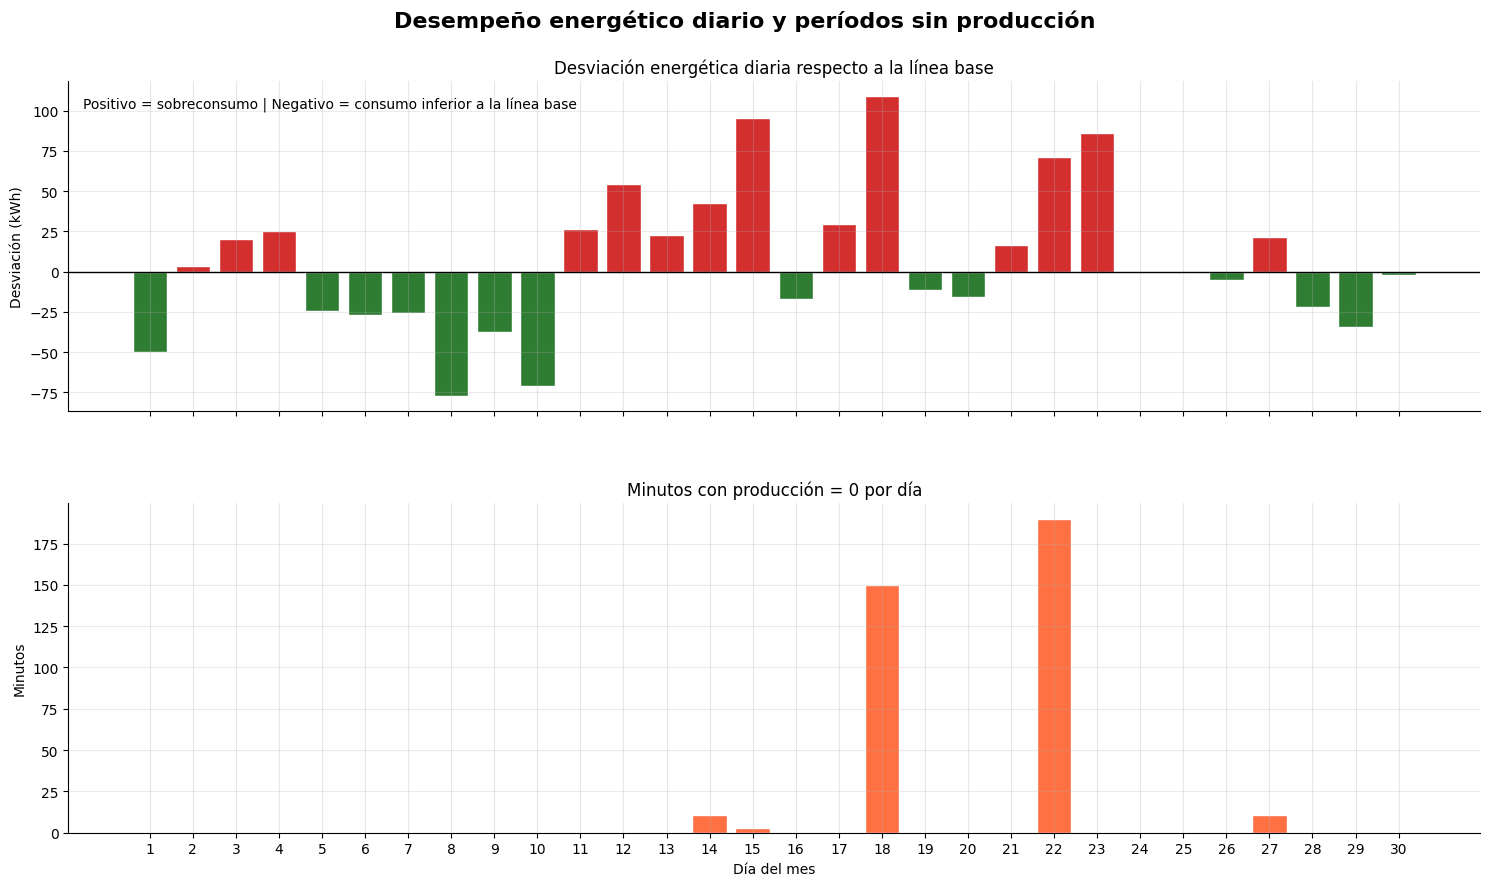

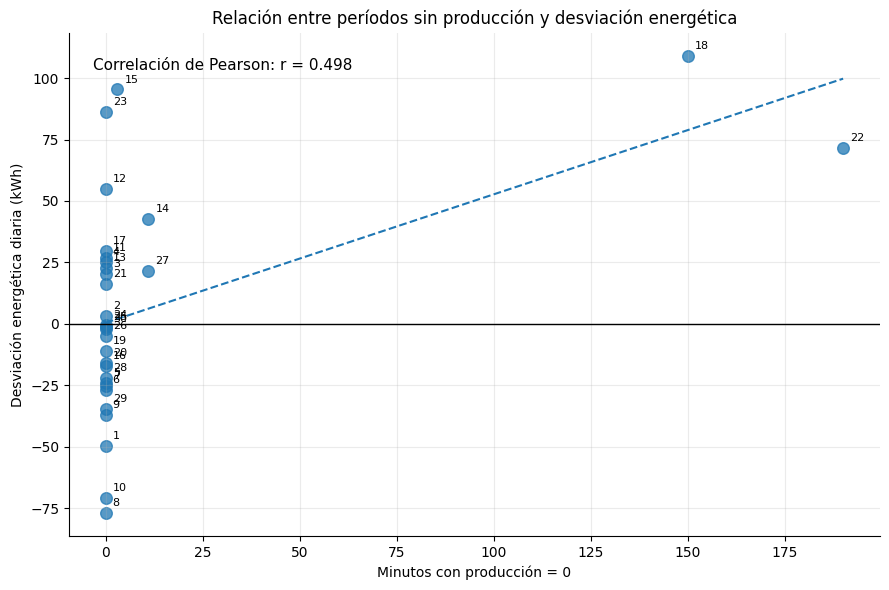

DÍAS CON MAYOR SOBRECONSUMO ENERGÉTICO
 Día Desviación energética (kWh)  Minutos con producción = 0
  18                     +109.09                         150
  15                      +95.36                           3
  23                      +86.11                           0
  22                      +71.42                         190
  12                      +54.69                           0

RELACIÓN ENTRE INACTIVIDAD Y DESVIACIÓN
Correlación de Pearson: 0.498

Nota: la correlación describe la asociación entre ambas variables, pero no demuestra causalidad.
Los minutos con producción = 0 tampoco deben interpretarse automáticamente como minutos en Estado Operacional = PARADO.


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 6. ANÁLISIS DIARIO DEL DESEMPEÑO ENERGÉTICO
# ============================================================
#
# Objetivo:
# 1. Identificar en qué días se concentra la desviación energética.
# 2. Comparar esos días con los períodos sin producción.
# 3. Evaluar si existe asociación entre ambas variables.
#
# IMPORTANTE:
# "Min_parados" representa minutos con Producción = 0.
# No implica necesariamente Estado Operacional = PARADO.
# ============================================================


# ============================================================
# 6.0 PREPARACIÓN DE LOS DATOS
# ============================================================

diario = desv_por_dia.copy().sort_index()

# Verificamos que existan las variables necesarias
columnas_requeridas = [
    "Desviacion_total_kWh",
    "Min_parados"
]

faltantes = [
    col for col in columnas_requeridas
    if col not in diario.columns
]

if faltantes:
    raise KeyError(
        f"Faltan las siguientes columnas en desv_por_dia: {faltantes}"
    )


# Número de día del mes
diario["Día"] = np.arange(1, len(diario) + 1)

# Nombre más preciso para interpretación
diario["Min_sin_produccion"] = diario["Min_parados"]


# ============================================================
# 6.1 DESVIACIÓN ENERGÉTICA DIARIA
# +
# 6.2 MINUTOS SIN PRODUCCIÓN
# ============================================================
#
# Se muestran en la misma figura y con el mismo eje temporal
# para facilitar la comparación visual.
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 9),
    sharex=True
)

fig.suptitle(
    "Desempeño energético diario y períodos sin producción",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# GRÁFICA 1
# Desviación energética diaria
# ------------------------------------------------------------

desviacion = diario["Desviacion_total_kWh"]

colores = [
    "#D32F2F" if valor > 0 else "#2E7D32"
    for valor in desviacion
]

axes[0].bar(
    diario["Día"],
    desviacion,
    color=colores,
    edgecolor="white"
)

axes[0].axhline(
    0,
    color="black",
    linewidth=1
)

axes[0].set_title(
    "Desviación energética diaria respecto a la línea base"
)

axes[0].set_ylabel(
    "Desviación (kWh)"
)

axes[0].grid(
    axis="y",
    alpha=0.25
)

# Leyenda explicativa
axes[0].text(
    0.01,
    0.95,
    "Positivo = sobreconsumo | Negativo = consumo inferior a la línea base",
    transform=axes[0].transAxes,
    va="top",
    fontsize=10
)


# ------------------------------------------------------------
# GRÁFICA 2
# Minutos con producción = 0
# ------------------------------------------------------------

axes[1].bar(
    diario["Día"],
    diario["Min_sin_produccion"],
    color="#FF7043",
    edgecolor="white"
)

axes[1].set_title(
    "Minutos con producción = 0 por día"
)

axes[1].set_xlabel(
    "Día del mes"
)

axes[1].set_ylabel(
    "Minutos"
)

axes[1].grid(
    axis="y",
    alpha=0.25
)

axes[1].set_xticks(
    diario["Día"]
)

plt.tight_layout()

plt.subplots_adjust(
    top=0.90,
    hspace=0.28
)

plt.show()


# ============================================================
# 6.3 RELACIÓN ENTRE INACTIVIDAD Y DESVIACIÓN ENERGÉTICA
# ============================================================
#
# Scatter:
#
# X = minutos con producción = 0
# Y = desviación energética diaria
#
# Permite evaluar visualmente si los días con más tiempo sin
# producción tienden también a presentar mayor sobreconsumo.
# ============================================================

x = diario["Min_sin_produccion"]
y = diario["Desviacion_total_kWh"]


# ------------------------------------------------------------
# Correlación de Pearson
# ------------------------------------------------------------

correlacion = x.corr(y)


# ------------------------------------------------------------
# Línea de tendencia descriptiva
# ------------------------------------------------------------

pendiente, intercepto = np.polyfit(
    x,
    y,
    1
)

x_linea = np.linspace(
    x.min(),
    x.max(),
    100
)

y_linea = (
    pendiente * x_linea
    + intercepto
)


# ------------------------------------------------------------
# Scatter
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    x,
    y,
    s=70,
    alpha=0.75
)

plt.plot(
    x_linea,
    y_linea,
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.xlabel(
    "Minutos con producción = 0"
)

plt.ylabel(
    "Desviación energética diaria (kWh)"
)

plt.title(
    "Relación entre períodos sin producción y desviación energética"
)

plt.grid(
    alpha=0.25
)


# Mostrar número de día sobre cada punto
for _, fila in diario.iterrows():

    plt.annotate(
        str(int(fila["Día"])),
        (
            fila["Min_sin_produccion"],
            fila["Desviacion_total_kWh"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )


# Mostrar correlación dentro de la gráfica
plt.text(
    0.03,
    0.95,
    f"Correlación de Pearson: r = {correlacion:.3f}",
    transform=plt.gca().transAxes,
    va="top",
    fontsize=11
)

plt.tight_layout()

plt.show()


# ============================================================
# 6.4 DÍAS CON MAYOR SOBRECONSUMO
# ============================================================
#
# Permite identificar qué jornadas deberían investigarse
# primero y cuánto tiempo sin producción registraron.
# ============================================================

dias_criticos = (
    diario[
        [
            "Día",
            "Desviacion_total_kWh",
            "Min_sin_produccion"
        ]
    ]
    .sort_values(
        "Desviacion_total_kWh",
        ascending=False
    )
    .head(5)
    .copy()
)

dias_criticos.columns = [
    "Día",
    "Desviación energética (kWh)",
    "Minutos con producción = 0"
]

print("=" * 70)
print("DÍAS CON MAYOR SOBRECONSUMO ENERGÉTICO")
print("=" * 70)

print(
    dias_criticos.to_string(
        index=False,
        formatters={
            "Desviación energética (kWh)":
                lambda x: f"{x:+,.2f}"
        }
    )
)


# ============================================================
# RESUMEN DEL ANÁLISIS
# ============================================================

print("\n" + "=" * 70)
print("RELACIÓN ENTRE INACTIVIDAD Y DESVIACIÓN")
print("=" * 70)

print(
    f"Correlación de Pearson: "
    f"{correlacion:.3f}"
)

print(
    "\nNota: la correlación describe la asociación entre ambas "
    "variables, pero no demuestra causalidad."
)

print(
    "Los minutos con producción = 0 tampoco deben interpretarse "
    "automáticamente como minutos en Estado Operacional = PARADO."
)

**El análisis diario evidencia que la desviación energética no es constante, sino que se concentra en jornadas específicas, mientras otros días presentan consumos inferiores a la línea base. La comparación con los minutos sin producción permite explorar si existe una asociación entre la inactividad y el sobreconsumo, aunque esta relación no implica causalidad y debe contrastarse con el Estado Operacional. Finalmente, el cruce Estado Operacional × Modo Operativo permite localizar con mayor precisión el origen de la desviación, identificando a PARADO × AUTOMATICO como la principal condición asociada al sobreconsumo.**

# 7. Impacto económico y priorización de acciones

**Pregunta clave: ¿Cuánto podría costar cada fuente de desviación y qué acción debería priorizarse?**

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 7. PRIORIZACIÓN DE OPORTUNIDADES DE MEJORA ENERGÉTICA
# ============================================================
#
# Criterio:
# La priorización se realiza con la DESVIACIÓN NETA:
#
#     Σ(E_real - E_base)
#
# No se suman únicamente las desviaciones positivas minuto
# a minuto, ya que eso eliminaría las compensaciones negativas
# y cambiaría la interpretación del KPI suministrado.
# ============================================================


df = df.copy()

# ------------------------------------------------------------
# Tarifa eléctrica
# ------------------------------------------------------------
# No fue suministrada en el caso.

TARIFA_ELECTRICA = None


# ============================================================
# FUNCIÓN DE RESUMEN
# ============================================================

def resumen_desviacion(dataframe, columnas_grupo):

    resumen = (
        dataframe
        .groupby(
            columnas_grupo,
            observed=True
        )
        .agg(
            Minutos=(
                "Desviacion (kWh)",
                "size"
            ),

            Desviacion_neta_kWh=(
                "Desviacion (kWh)",
                "sum"
            ),

            Desviacion_media_kWh=(
                "Desviacion (kWh)",
                "mean"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Peso sobre la desviación neta total
    # --------------------------------------------------------

    desviacion_total = (
        resumen["Desviacion_neta_kWh"].sum()
    )

    if desviacion_total != 0:

        resumen["Peso_desviacion_pct"] = (
            resumen["Desviacion_neta_kWh"]
            / desviacion_total
            * 100
        )

    else:

        resumen["Peso_desviacion_pct"] = 0


    # --------------------------------------------------------
    # Impacto económico
    # --------------------------------------------------------
    # Solo puede calcularse si existe una tarifa configurada.

    if TARIFA_ELECTRICA is not None:

        resumen["Impacto_economico"] = (
            resumen["Desviacion_neta_kWh"]
            * TARIFA_ELECTRICA
        )

    else:

        resumen["Impacto_economico"] = np.nan


    return resumen


# ============================================================
# 7.1 PRIORIZACIÓN POR ESTADO OPERACIONAL
# ============================================================

estado = resumen_desviacion(
    df,
    ["Estado Operacional"]
)

estado = (
    estado
    .sort_values(
        "Desviacion_neta_kWh",
        ascending=False
    )
    .reset_index(drop=True)
)

estado["Prioridad"] = (
    np.arange(1, len(estado) + 1)
)


print("=" * 105)
print("PRIORIZACIÓN POR ESTADO OPERACIONAL")
print("=" * 105)

for _, fila in estado.iterrows():

    print(
        f"{int(fila['Prioridad'])}. "
        f"{fila['Estado Operacional']:12s} │ "
        f"Desviación neta: "
        f"{fila['Desviacion_neta_kWh']:>+9,.2f} kWh │ "
        f"{fila['Peso_desviacion_pct']:>6.2f}% │ "
        f"{int(fila['Minutos']):>6,} min │ "
        f"Media: "
        f"{fila['Desviacion_media_kWh']:>+.4f} kWh/min"
    )


# ============================================================
# 7.2 ANÁLISIS POR MODO OPERATIVO
# ============================================================

modo = resumen_desviacion(
    df,
    ["Modo Operativo"]
)

modo = (
    modo
    .sort_values(
        "Desviacion_neta_kWh",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 105)
print("ANÁLISIS POR MODO OPERATIVO")
print("=" * 105)

for _, fila in modo.iterrows():

    print(
        f"{fila['Modo Operativo']:12s} │ "
        f"Desviación neta: "
        f"{fila['Desviacion_neta_kWh']:>+9,.2f} kWh │ "
        f"{fila['Peso_desviacion_pct']:>6.2f}% │ "
        f"{int(fila['Minutos']):>6,} min │ "
        f"Media: "
        f"{fila['Desviacion_media_kWh']:>+.4f} kWh/min"
    )


# ============================================================
# 7.3 PRIORIZACIÓN POR ESTADO × MODO OPERATIVO
# ============================================================

estado_modo = resumen_desviacion(
    df,
    [
        "Estado Operacional",
        "Modo Operativo"
    ]
)

estado_modo["Condicion"] = (
    estado_modo["Estado Operacional"].astype(str)
    + " × "
    + estado_modo["Modo Operativo"].astype(str)
)

estado_modo = (
    estado_modo
    .sort_values(
        "Desviacion_neta_kWh",
        ascending=False
    )
    .reset_index(drop=True)
)

estado_modo["Prioridad"] = (
    np.arange(
        1,
        len(estado_modo) + 1
    )
)


print("\n" + "=" * 105)
print("PRIORIZACIÓN POR ESTADO × MODO")
print("=" * 105)

for _, fila in estado_modo.iterrows():

    print(
        f"{int(fila['Prioridad'])}. "
        f"{fila['Condicion']:26s} │ "
        f"{fila['Desviacion_neta_kWh']:>+9,.2f} kWh │ "
        f"{fila['Peso_desviacion_pct']:>6.2f}% │ "
        f"{int(fila['Minutos']):>6,} min │ "
        f"Media: "
        f"{fila['Desviacion_media_kWh']:>+.4f} kWh/min"
    )


# ============================================================
# 7.4 DÍA DE LA SEMANA — ANÁLISIS EXPLORATORIO
# ============================================================
#
# Se calcula primero cada fecha y posteriormente el promedio
# por día de semana para evitar que un día tenga mayor peso
# simplemente porque aparece 5 veces en lugar de 4.
# ============================================================

df["Fecha"] = df["Timestamp"].dt.date

mapa_dias = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

df["Dia_semana"] = (
    df["Timestamp"]
    .dt.day_name()
    .map(mapa_dias)
)


por_fecha = (
    df
    .groupby(
        ["Fecha", "Dia_semana"],
        observed=True
    )
    .agg(
        Desviacion_dia_kWh=(
            "Desviacion (kWh)",
            "sum"
        )
    )
    .reset_index()
)


dia_semana = (
    por_fecha
    .groupby(
        "Dia_semana",
        observed=True
    )
    .agg(
        Dias_observados=(
            "Fecha",
            "nunique"
        ),

        Desviacion_total_kWh=(
            "Desviacion_dia_kWh",
            "sum"
        ),

        Desviacion_media_dia_kWh=(
            "Desviacion_dia_kWh",
            "mean"
        )
    )
    .reset_index()
)


orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

dia_semana["Dia_semana"] = pd.Categorical(
    dia_semana["Dia_semana"],
    categories=orden_dias,
    ordered=True
)

dia_semana = (
    dia_semana
    .sort_values("Dia_semana")
)


print("\n" + "=" * 100)
print("ANÁLISIS EXPLORATORIO POR DÍA DE LA SEMANA")
print("=" * 100)

for _, fila in dia_semana.iterrows():

    print(
        f"{fila['Dia_semana']:10s} │ "
        f"{int(fila['Dias_observados'])} días │ "
        f"Neto total: "
        f"{fila['Desviacion_total_kWh']:>+9,.2f} kWh │ "
        f"Media/día: "
        f"{fila['Desviacion_media_dia_kWh']:>+8,.2f} kWh"
    )


# ============================================================
# 7.5 IMPACTO ECONÓMICO
# ============================================================

print("\n" + "=" * 100)
print("IMPACTO ECONÓMICO")
print("=" * 100)

if TARIFA_ELECTRICA is None:

    print(
        "No es posible cuantificar el impacto monetario "
        "porque la tarifa eléctrica ($/kWh) no fue suministrada."
    )

    print(
        "\nEl indicador queda parametrizado:"
    )

    print(
        "Impacto económico = "
        "Desviación energética × Tarifa eléctrica"
    )

else:

    desviacion_total = (
        df["Desviacion (kWh)"].sum()
    )

    impacto_total = (
        desviacion_total
        * TARIFA_ELECTRICA
    )

    print(
        f"Impacto económico total: "
        f"{impacto_total:,.2f}"
    )

PRIORIZACIÓN POR ESTADO OPERACIONAL
1. PARADO       │ Desviación neta:   +128.11 kWh │  62.95% │    441 min │ Media: +0.2905 kWh/min
2. PARANDO      │ Desviación neta:    +29.40 kWh │  14.45% │    112 min │ Media: +0.2625 kWh/min
3. ARRANQUE     │ Desviación neta:    +27.49 kWh │  13.51% │    110 min │ Media: +0.2499 kWh/min
4. OPERANDO     │ Desviación neta:    +18.50 kWh │   9.09% │ 42,537 min │ Media: +0.0004 kWh/min

ANÁLISIS POR MODO OPERATIVO
AUTOMATICO   │ Desviación neta:   +175.13 kWh │  86.06% │ 42,819 min │ Media: +0.0041 kWh/min
MANUAL       │ Desviación neta:    +28.36 kWh │  13.94% │    381 min │ Media: +0.0744 kWh/min

PRIORIZACIÓN POR ESTADO × MODO
1. PARADO × AUTOMATICO        │   +127.77 kWh │  62.79% │    436 min │ Media: +0.2931 kWh/min
2. PARANDO × AUTOMATICO       │    +25.99 kWh │  12.77% │    102 min │ Media: +0.2548 kWh/min
3. ARRANQUE × AUTOMATICO      │    +20.71 kWh │  10.18% │     78 min │ Media: +0.2656 kWh/min
4. OPERANDO × MANUAL          │    +17.84 kWh

La priorización evidencia que la desviación energética se concentra principalmente fuera del régimen estable de producción. El estado PARADO representa el 62.95% de la desviación neta total y, al combinar Estado Operacional y Modo Operativo, PARADO × AUTOMATICO emerge como la principal condición a investigar, con el 62.79%. Aunque el modo MANUAL tiene menor impacto absoluto, presenta una desviación media por minuto significativamente mayor, por lo que constituye una oportunidad secundaria de análisis. Los resultados por día de la semana se consideran exploratorios debido al limitado número de observaciones por categoría.

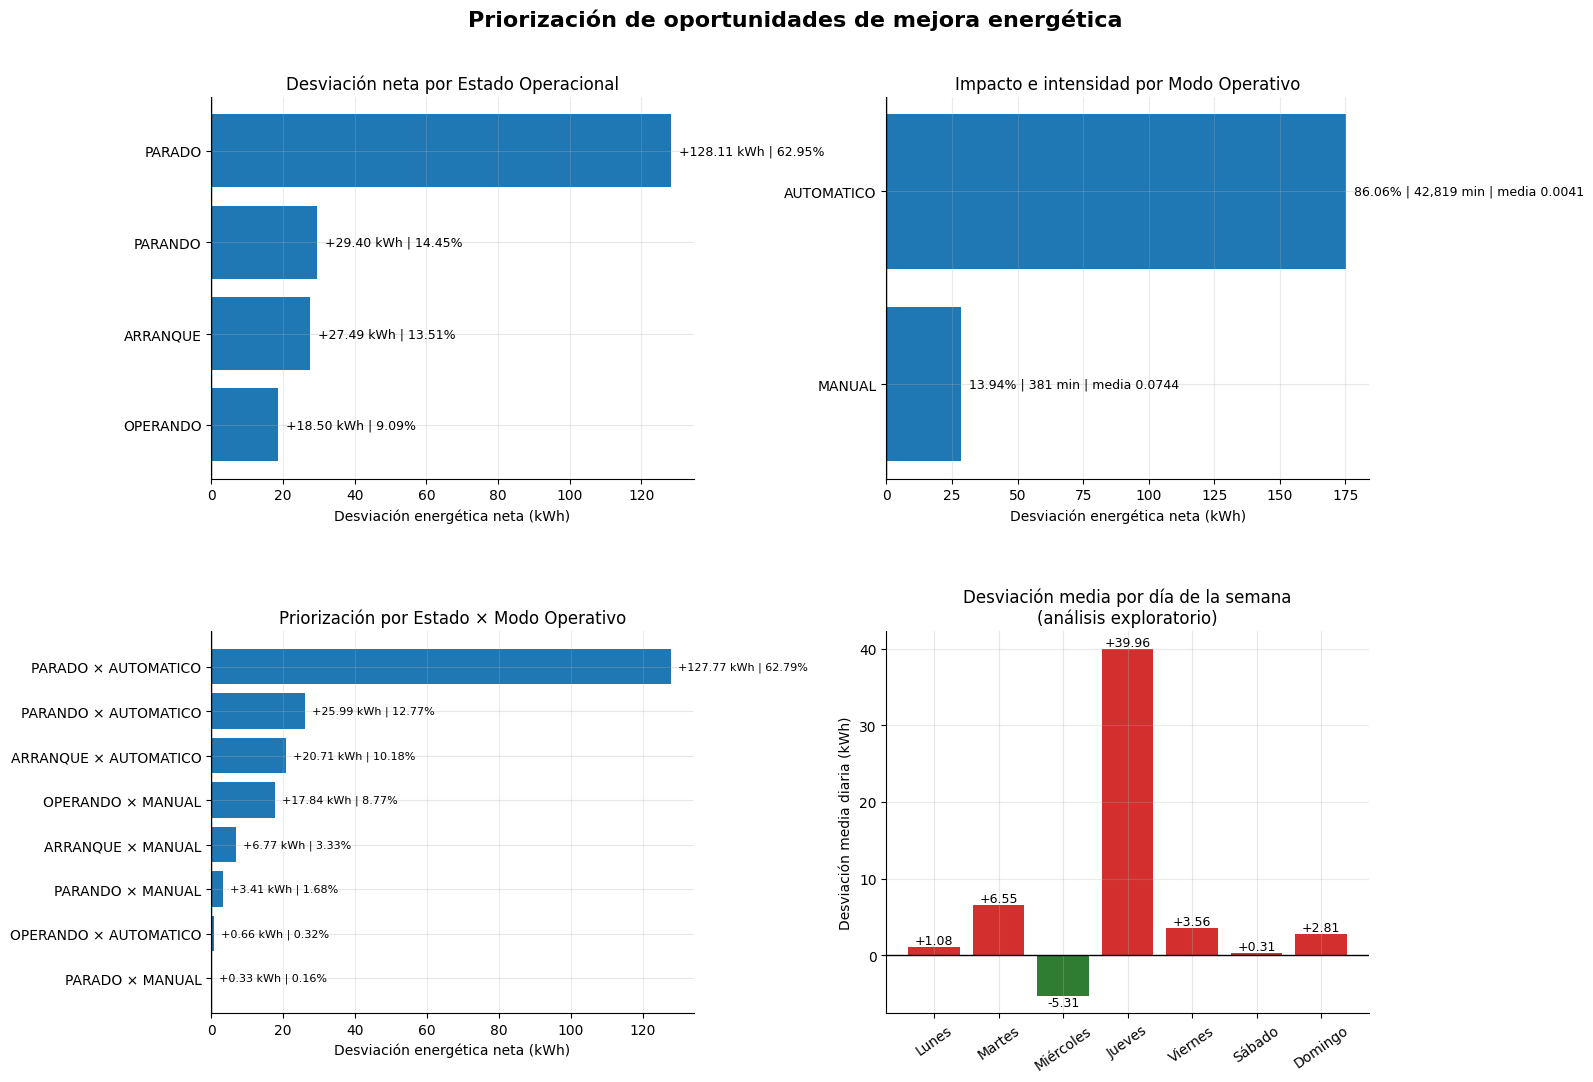

In [41]:
# ============================================================
# VISUALIZACIÓN  DE LA PRIORIZACIÓN
# ============================================================
#
# IMPORTANTE:
# Las gráficas utilizan DESVIACIÓN NETA, no la suma
# de desviaciones positivas minuto a minuto.
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

fig.suptitle(
    "Priorización de oportunidades de mejora energética",
    fontsize=16,
    fontweight="bold"
)


# ============================================================
# 1. ESTADO OPERACIONAL
# ============================================================

estado_plot = (
    estado
    .sort_values(
        "Desviacion_neta_kWh",
        ascending=True
    )
)

axes[0, 0].barh(
    estado_plot["Estado Operacional"],
    estado_plot["Desviacion_neta_kWh"]
)

axes[0, 0].axvline(
    0,
    color="black",
    linewidth=1
)

axes[0, 0].set_title(
    "Desviación neta por Estado Operacional"
)

axes[0, 0].set_xlabel(
    "Desviación energética neta (kWh)"
)

axes[0, 0].grid(
    axis="x",
    alpha=0.25
)


for i, (_, fila) in enumerate(estado_plot.iterrows()):

    valor = fila["Desviacion_neta_kWh"]

    axes[0, 0].text(
        valor,
        i,
        (
            f"  {valor:+.2f} kWh "
            f"| {fila['Peso_desviacion_pct']:.2f}%"
        ),
        va="center",
        fontsize=9
    )


# ============================================================
# 2. MODO OPERATIVO
# ============================================================

modo_plot = (
    modo
    .sort_values(
        "Desviacion_neta_kWh",
        ascending=True
    )
)

axes[0, 1].barh(
    modo_plot["Modo Operativo"],
    modo_plot["Desviacion_neta_kWh"]
)

axes[0, 1].axvline(
    0,
    color="black",
    linewidth=1
)

axes[0, 1].set_title(
    "Impacto e intensidad por Modo Operativo"
)

axes[0, 1].set_xlabel(
    "Desviación energética neta (kWh)"
)

axes[0, 1].grid(
    axis="x",
    alpha=0.25
)


for i, (_, fila) in enumerate(modo_plot.iterrows()):

    valor = fila["Desviacion_neta_kWh"]

    axes[0, 1].text(
        valor,
        i,
        (
            f"  {fila['Peso_desviacion_pct']:.2f}% "
            f"| {int(fila['Minutos']):,} min "
            f"| media {fila['Desviacion_media_kWh']:.4f}"
        ),
        va="center",
        fontsize=9
    )


# ============================================================
# 3. ESTADO × MODO OPERATIVO
# ============================================================

estado_modo_plot = (
    estado_modo
    .sort_values(
        "Desviacion_neta_kWh",
        ascending=True
    )
)

axes[1, 0].barh(
    estado_modo_plot["Condicion"],
    estado_modo_plot["Desviacion_neta_kWh"]
)

axes[1, 0].axvline(
    0,
    color="black",
    linewidth=1
)

axes[1, 0].set_title(
    "Priorización por Estado × Modo Operativo"
)

axes[1, 0].set_xlabel(
    "Desviación energética neta (kWh)"
)

axes[1, 0].grid(
    axis="x",
    alpha=0.25
)


for i, (_, fila) in enumerate(
    estado_modo_plot.iterrows()
):

    valor = fila["Desviacion_neta_kWh"]

    axes[1, 0].text(
        valor,
        i,
        (
            f"  {valor:+.2f} kWh "
            f"| {fila['Peso_desviacion_pct']:.2f}%"
        ),
        va="center",
        fontsize=8
    )


# ============================================================
# 4. DÍA DE LA SEMANA
# ============================================================

valores_dia = (
    dia_semana["Desviacion_media_dia_kWh"]
)

colores_dia = [
    "#D32F2F" if valor > 0 else "#2E7D32"
    for valor in valores_dia
]

axes[1, 1].bar(
    dia_semana["Dia_semana"].astype(str),
    valores_dia,
    color=colores_dia
)

axes[1, 1].axhline(
    0,
    color="black",
    linewidth=1
)

axes[1, 1].set_title(
    "Desviación media por día de la semana\n"
    "(análisis exploratorio)"
)

axes[1, 1].set_ylabel(
    "Desviación media diaria (kWh)"
)

axes[1, 1].tick_params(
    axis="x",
    rotation=35
)

axes[1, 1].grid(
    axis="y",
    alpha=0.25
)


# Etiquetas
for i, valor in enumerate(valores_dia):

    axes[1, 1].text(
        i,
        valor,
        f"{valor:+.2f}",
        ha="center",
        va="bottom" if valor >= 0 else "top",
        fontsize=9
    )


# ============================================================
# AJUSTES FINALES
# ============================================================

plt.tight_layout()

plt.subplots_adjust(
    top=0.90,
    hspace=0.40,
    wspace=0.40
)

plt.show()

> **La desviación energética se concentra principalmente en condiciones de inactividad y transición. `PARADO` aporta el 62.95% de la desviación neta total, y el cruce `PARADO × AUTOMATICO` concentra por sí solo el 62.79%, por lo que constituye la principal condición a investigar. Aunque el modo `MANUAL` tiene menor impacto absoluto, presenta una desviación media por minuto mucho mayor, lo que sugiere revisar también su eficiencia operativa. El patrón por día de la semana es exploratorio y no permite concluir una tendencia recurrente con un solo mes de datos.**


## 7.1 Matriz de priorización de acciones

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 7. PRIORIZACIÓN DE CONDICIONES OPERATIVAS
# ============================================================
#
# La priorización se basa en:
#   1. Desviación energética neta
#   2. Peso sobre la desviación total
#   3. Exposición (minutos)
#   4. Intensidad media de la desviación
#
# No se interpreta la desviación como ahorro potencial
# garantizado ni como costo económico, ya que no se dispone
# de tarifa eléctrica.
# ============================================================


# ------------------------------------------------------------
# 1. RESUMEN ESTADO × MODO
# ------------------------------------------------------------

priorizacion = (
    df.groupby(
        ["Estado Operacional", "Modo Operativo"],
        observed=True
    )
    .agg(
        Minutos=("Desviacion (kWh)", "size"),
        Desviacion_neta_kWh=("Desviacion (kWh)", "sum"),
        Desviacion_media_kWh=("Desviacion (kWh)", "mean")
    )
    .reset_index()
)


# Nombre combinado de la condición
priorizacion["Condicion"] = (
    priorizacion["Estado Operacional"].astype(str)
    + " × "
    + priorizacion["Modo Operativo"].astype(str)
)


# ------------------------------------------------------------
# 2. PESO SOBRE LA DESVIACIÓN NETA TOTAL
# ------------------------------------------------------------

desviacion_total = priorizacion["Desviacion_neta_kWh"].sum()

priorizacion["Peso_desviacion_pct"] = (
    priorizacion["Desviacion_neta_kWh"]
    / desviacion_total
    * 100
)


# ------------------------------------------------------------
# 3. ORDEN DE PRIORIDAD
# ------------------------------------------------------------

priorizacion = (
    priorizacion
    .sort_values(
        "Desviacion_neta_kWh",
        ascending=False
    )
    .reset_index(drop=True)
)

priorizacion["Prioridad"] = (
    np.arange(1, len(priorizacion) + 1)
)


# ------------------------------------------------------------
# 4. SIGUIENTE VALIDACIÓN SUGERIDA
# ------------------------------------------------------------
#
# Son hipótesis de investigación, NO causas demostradas.
# ------------------------------------------------------------

def sugerir_validacion(fila):

    estado = fila["Estado Operacional"]
    modo = fila["Modo Operativo"]

    if estado == "PARADO" and modo == "AUTOMATICO":
        return (
            "Revisar consumos activos y secuencia "
            "automática durante las paradas"
        )

    elif estado == "PARANDO":
        return (
            "Analizar duración y consumo durante "
            "la secuencia de parada"
        )

    elif estado == "ARRANQUE":
        return (
            "Analizar duración y consumo durante "
            "la secuencia de arranque"
        )

    elif estado == "OPERANDO" and modo == "MANUAL":
        return (
            "Revisar eventos manuales y condiciones "
            "operativas asociadas"
        )

    elif modo == "MANUAL":
        return (
            "Investigar por qué la operación manual "
            "presenta mayor intensidad de desviación"
        )

    else:
        return "Mantener como condición secundaria de análisis"


priorizacion["Siguiente_validacion"] = (
    priorizacion.apply(
        sugerir_validacion,
        axis=1
    )
)


# ============================================================
# 5. TABLA DE PRIORIZACIÓN
# ============================================================

print("=" * 125)
print("PRIORIZACIÓN DE CONDICIONES OPERATIVAS")
print("=" * 125)

for _, fila in priorizacion.iterrows():

    print(
        f"{int(fila['Prioridad']):>2}. "
        f"{fila['Condicion']:<28} │ "
        f"{fila['Desviacion_neta_kWh']:>+9.2f} kWh │ "
        f"{fila['Peso_desviacion_pct']:>6.2f}% │ "
        f"{int(fila['Minutos']):>6,} min │ "
        f"media {fila['Desviacion_media_kWh']:>+.4f} kWh/min"
    )

    print(
        f"    → {fila['Siguiente_validacion']}"
    )

print("=" * 125)


# ============================================================
# 6. IMPACTO ECONÓMICO
# ============================================================

print("\nIMPACTO ECONÓMICO")

print(
    "No es posible cuantificar el impacto monetario porque "
    "la tarifa eléctrica ($/kWh) no fue suministrada."
)

print(
    "El indicador queda parametrizado como:"
)

print(
    "Impacto económico = "
    "Desviación energética × Tarifa eléctrica"
)

PRIORIZACIÓN DE CONDICIONES OPERATIVAS
 1. PARADO × AUTOMATICO          │   +127.77 kWh │  62.79% │    436 min │ media +0.2931 kWh/min
    → Revisar consumos activos y secuencia automática durante las paradas
 2. PARANDO × AUTOMATICO         │    +25.99 kWh │  12.77% │    102 min │ media +0.2548 kWh/min
    → Analizar duración y consumo durante la secuencia de parada
 3. ARRANQUE × AUTOMATICO        │    +20.71 kWh │  10.18% │     78 min │ media +0.2656 kWh/min
    → Analizar duración y consumo durante la secuencia de arranque
 4. OPERANDO × MANUAL            │    +17.84 kWh │   8.77% │    334 min │ media +0.0534 kWh/min
    → Revisar eventos manuales y condiciones operativas asociadas
 5. ARRANQUE × MANUAL            │     +6.77 kWh │   3.33% │     32 min │ media +0.2117 kWh/min
    → Analizar duración y consumo durante la secuencia de arranque
 6. PARANDO × MANUAL             │     +3.41 kWh │   1.68% │     10 min │ media +0.3411 kWh/min
    → Analizar duración y consumo durante la s

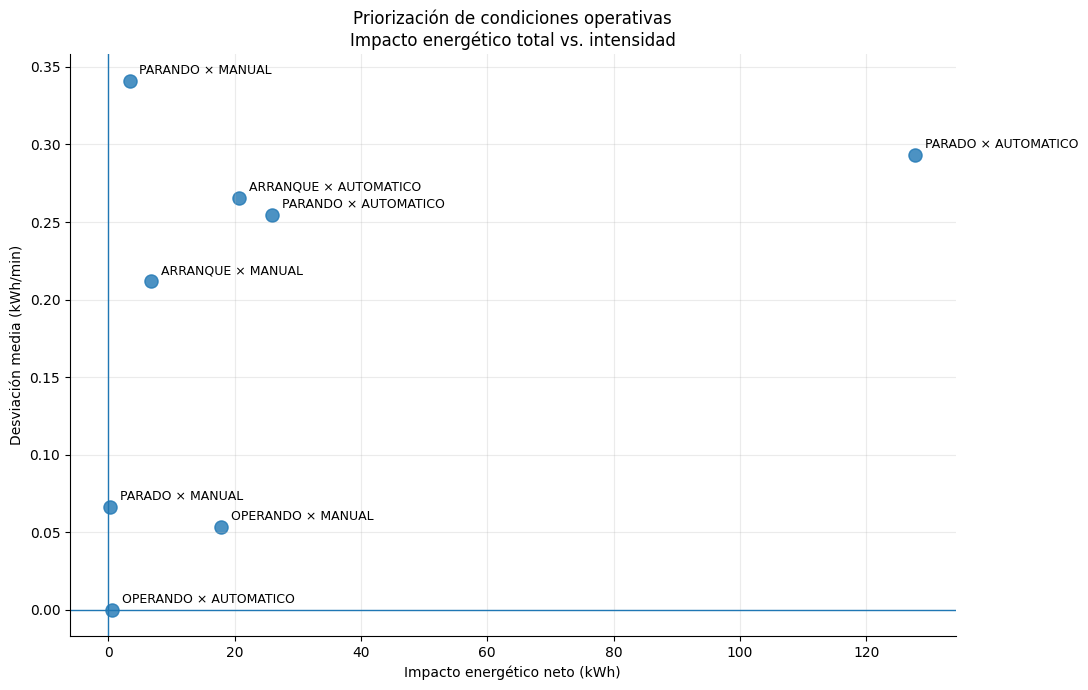

In [43]:
# ============================================================
# 7. GRÁFICA DE PRIORIZACIÓN:
#    IMPACTO TOTAL VS INTENSIDAD
# ============================================================

plt.figure(figsize=(11, 7))


# Solo condiciones con desviación neta positiva
plot_prioridad = priorizacion[
    priorizacion["Desviacion_neta_kWh"] > 0
].copy()


plt.scatter(
    plot_prioridad["Desviacion_neta_kWh"],
    plot_prioridad["Desviacion_media_kWh"],
    s=90,
    alpha=0.8
)


# Etiquetar cada condición
for _, fila in plot_prioridad.iterrows():

    plt.annotate(
        fila["Condicion"],
        (
            fila["Desviacion_neta_kWh"],
            fila["Desviacion_media_kWh"]
        ),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=9
    )


plt.axhline(
    0,
    linewidth=1
)

plt.axvline(
    0,
    linewidth=1
)


plt.xlabel(
    "Impacto energético neto (kWh)"
)

plt.ylabel(
    "Desviación media (kWh/min)"
)

plt.title(
    "Priorización de condiciones operativas\n"
    "Impacto energético total vs. intensidad"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

### Lectura de la matriz de priorización

La tabla anterior responde directamente la pregunta del negocio: **¿qué acción debería priorizarse?**

La priorización definitiva de acciones deberá complementarse posteriormente con criterios de impacto económico y factibilidad de implementación, una vez se disponga de la tarifa eléctrica y de información operativa adicional del cliente.

# 8. Hallazgos principales

### Hallazgo 1: El desempeño agregado está muy próximo a la línea base

El cumplimiento mensual es cercano al 100% y la desviación energética neta es de aproximadamente **+203.49 kWh**. Sin embargo, el resultado agregado oculta variaciones importantes entre días y condiciones operativas.

**Implicación de producto:** el KPI global debe complementarse con vistas que permitan identificar cuándo y bajo qué condiciones ocurre la desviación.


### Hallazgo 2: La desviación se concentra fuera de la operación estable

Los estados `PARADO`, `PARANDO` y `ARRANQUE` concentran aproximadamente **90.9% de la desviación neta**, aunque representan una fracción reducida del período analizado. `PARADO` es el principal contribuyente, con **62.95%**.

**Implicación de producto:** las condiciones de inactividad y transición deben tener mayor visibilidad dentro del análisis.


### Hallazgo 3: `PARADO × AUTOMATICO` es la principal condición a investigar

El cruce entre Estado Operacional y Modo Operativo muestra que `PARADO × AUTOMATICO` concentra aproximadamente **62.79% de la desviación neta total**.

Esto no identifica todavía la causa física del consumo, pero permite definir con precisión **dónde debería comenzar la investigación operacional**.


### Hallazgo 4: El modo MANUAL presenta mayor intensidad de desviación

Aunque el modo `MANUAL` tiene menor impacto energético absoluto, su desviación media por minuto es considerablemente superior a la del modo `AUTOMATICO`.

**Implicación:** las operaciones manuales representan una oportunidad secundaria de análisis, especialmente para identificar las condiciones que generan esta mayor intensidad.


### Hallazgo 5: La desviación es episódica, no uniforme

El comportamiento diario presenta jornadas con sobreconsumo relevante y otras con consumo inferior a la línea base. Esto confirma que el resultado mensual es producto de comportamientos operativos diferentes que se compensan parcialmente.

Los patrones por día de la semana se consideran **exploratorios**, ya que solo se dispone de un mes de información.

# 9. Conclusiones y recomendaciones para la toma de decisiones

### ¿La planta consume más o menos de lo esperado?

Durante junio se presenta una desviación energética neta positiva de aproximadamente **+203.49 kWh** respecto a la línea base. Aunque el cumplimiento agregado es cercano al 100%, existen oportunidades de mejora concentradas en condiciones operativas específicas.


### ¿Dónde se concentra la desviación?

La principal contribución proviene de los períodos de inactividad y transición. `PARADO` representa **62.95%** de la desviación neta y, al cruzarlo con el modo operativo, `PARADO × AUTOMATICO` concentra **62.79%** del total.


### ¿Qué debería investigarse primero?

La primera prioridad es analizar qué ocurre durante `PARADO × AUTOMATICO`, revisando los consumos activos y las secuencias automáticas asociadas a la parada. Posteriormente deberían analizarse las transiciones de `PARANDO` y `ARRANQUE`, así como las operaciones manuales por su mayor intensidad de desviación.

Estas condiciones representan prioridades de investigación, no causas raíz demostradas.


### ¿Cuál es el impacto económico?

No es posible cuantificarlo con los insumos suministrados porque no se proporcionó la tarifa eléctrica ($/kWh).

El indicador debe quedar parametrizado dentro del producto:

**Impacto económico = Desviación energética × Tarifa eléctrica**